# Project Overview

This notebook builds a compact, recruiter-friendly executive dashboard from the cleaned datasets and analytical outputs generated by previous notebooks.

In [1]:
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 180

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)
logger = logging.getLogger("executive_dashboard")

## Configuration

Paths and reusable helper functions are configured here so the dashboard can adapt to available files.

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed").exists():
            return candidate
    return start


def ensure_directory(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def safe_read_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        logger.warning("Missing file: %s", path)
        return None
    try:
        df = pd.read_csv(path)
        logger.info("Loaded %s with shape %s", path.name, df.shape)
        return df
    except Exception as exc:
        logger.exception("Failed reading %s", path)
        logger.warning("Reason: %s", exc)
        return None


def get_first_existing_column(df: pd.DataFrame | None, candidates: list[str]) -> str | None:
    if df is None:
        return None
    for col in candidates:
        if col in df.columns:
            return col
    return None


def to_numeric_safe(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"

ensure_directory(OUTPUT_DIR)
ensure_directory(FIGURES_DIR)

logger.info("Project root: %s", PROJECT_ROOT)
logger.info("Processed data path: %s", DATA_DIR)
logger.info("Output path: %s", OUTPUT_DIR)
logger.info("Figure path: %s", FIGURES_DIR)

2026-07-11 12:46:33,592 - INFO - Project root: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics
2026-07-11 12:46:33,593 - INFO - Processed data path: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/data/processed
2026-07-11 12:46:33,593 - INFO - Output path: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs
2026-07-11 12:46:33,593 - INFO - Figure path: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/figures


## Load Processed Data

All cleaned base datasets are loaded from `data/processed`.

In [3]:
customers = safe_read_csv(DATA_DIR / "financial_customers_clean.csv")
transactions = safe_read_csv(DATA_DIR / "financial_transactions_clean.csv")
monthly_revenue = safe_read_csv(DATA_DIR / "monthly_revenue_clean.csv")

print("customers:", None if customers is None else customers.shape)
print("transactions:", None if transactions is None else transactions.shape)
print("monthly_revenue:", None if monthly_revenue is None else monthly_revenue.shape)

2026-07-11 12:46:33,656 - INFO - Loaded financial_customers_clean.csv with shape (20000, 36)
2026-07-11 12:46:34,280 - INFO - Loaded financial_transactions_clean.csv with shape (329202, 30)
2026-07-11 12:46:34,283 - INFO - Loaded monthly_revenue_clean.csv with shape (36, 18)


customers: (20000, 36)
transactions: (329202, 30)
monthly_revenue: (36, 18)


## Load Outputs from Previous Notebooks

Analytical outputs from notebooks 01 to 07 are loaded dynamically from `outputs/` when available.

In [4]:
output_files = {
    "revenue_analysis": OUTPUT_DIR / "revenue_analysis.csv",
    "forecast_results": OUTPUT_DIR / "forecast_results.csv",
    "churn_predictions": OUTPUT_DIR / "churn_predictions.csv",
    "high_risk_customers": OUTPUT_DIR / "high_risk_customers.csv",
    "cohort_summary": OUTPUT_DIR / "cohort_summary.csv",
    "retention_kpis": OUTPUT_DIR / "retention_kpis.csv",
    "rfm_table": OUTPUT_DIR / "rfm_table.csv",
    "segment_summary": OUTPUT_DIR / "segment_summary.csv",
    "profitability_summary": OUTPUT_DIR / "profitability_summary.csv",
    "customer_profitability": OUTPUT_DIR / "customer_profitability.csv",
    "product_profitability": OUTPUT_DIR / "product_profitability.csv",
    "top_profit_customers": OUTPUT_DIR / "top_profit_customers.csv",
    "model_evaluation_metrics": OUTPUT_DIR / "model_evaluation_metrics.csv",
}

outputs_data = {name: safe_read_csv(path) for name, path in output_files.items()}
loaded_count = sum(df is not None for df in outputs_data.values())
print(f"Loaded analytical outputs: {loaded_count}/{len(outputs_data)}")

2026-07-11 12:46:34,292 - INFO - Loaded revenue_analysis.csv with shape (4, 2)
2026-07-11 12:46:34,294 - INFO - Loaded forecast_results.csv with shape (12, 2)
2026-07-11 12:46:34,302 - INFO - Loaded churn_predictions.csv with shape (20000, 5)
2026-07-11 12:46:34,311 - INFO - Loaded high_risk_customers.csv with shape (5284, 21)
2026-07-11 12:46:34,312 - INFO - Loaded cohort_summary.csv with shape (35, 14)
2026-07-11 12:46:34,313 - INFO - Loaded retention_kpis.csv with shape (1, 12)
2026-07-11 12:46:34,349 - INFO - Loaded rfm_table.csv with shape (20000, 27)
2026-07-11 12:46:34,351 - INFO - Loaded segment_summary.csv with shape (10, 17)
2026-07-11 12:46:34,353 - INFO - Loaded profitability_summary.csv with shape (4, 2)
2026-07-11 12:46:34,375 - INFO - Loaded customer_profitability.csv with shape (20000, 11)
2026-07-11 12:46:34,377 - INFO - Loaded product_profitability.csv with shape (6, 6)
2026-07-11 12:46:34,378 - INFO - Loaded top_profit_customers.csv with shape (20, 11)
2026-07-11 12:

Loaded analytical outputs: 13/13


## Validate Required Files

Base processed files are mandatory for the dashboard. Analytical output files are optional and are skipped gracefully if missing.

In [5]:
required_processed = {
    "financial_customers_clean.csv": customers,
    "financial_transactions_clean.csv": transactions,
    "monthly_revenue_clean.csv": monthly_revenue,
}

missing_required = [name for name, df in required_processed.items() if df is None]
if missing_required:
    raise FileNotFoundError(f"Missing required processed datasets: {missing_required}")

validation_rows = []
for name, path in output_files.items():
    validation_rows.append(
        {
            "file": path.name,
            "required": False,
            "available": outputs_data[name] is not None,
            "rows": None if outputs_data[name] is None else int(outputs_data[name].shape[0]),
        }
    )

validation_df = pd.DataFrame(validation_rows)
print(validation_df.to_string(index=False))

                        file  required  available  rows
        revenue_analysis.csv     False       True     4
        forecast_results.csv     False       True    12
       churn_predictions.csv     False       True 20000
     high_risk_customers.csv     False       True  5284
          cohort_summary.csv     False       True    35
          retention_kpis.csv     False       True     1
               rfm_table.csv     False       True 20000
         segment_summary.csv     False       True    10
   profitability_summary.csv     False       True     4
  customer_profitability.csv     False       True 20000
   product_profitability.csv     False       True     6
    top_profit_customers.csv     False       True    20
model_evaluation_metrics.csv     False       True     5


## Executive Dashboard Overview

The dashboard assembles executive KPIs and compact visual summaries for revenue, customer health, forecasting, churn, cohort retention, RFM segmentation, and profitability.

## KPI Preparation

Core executive metrics are computed from processed datasets and available analytical outputs.

In [6]:
# Revenue and profit metrics
transaction_revenue_col = get_first_existing_column(transactions, ["net_revenue", "gross_amount"]) 
transaction_profit_col = get_first_existing_column(transactions, ["profit"]) 

total_revenue = float(to_numeric_safe(transactions[transaction_revenue_col]).fillna(0).sum())

if transaction_profit_col is not None:
    total_profit = float(to_numeric_safe(transactions[transaction_profit_col]).fillna(0).sum())
else:
    cost_cols = [c for c in ["processing_fee", "refund_amount", "support_cost", "marketing_cost", "operational_cost"] if c in transactions.columns]
    derived_cost = transactions[cost_cols].apply(to_numeric_safe).fillna(0).sum(axis=1)
    total_profit = float(to_numeric_safe(transactions[transaction_revenue_col]).fillna(0).sub(derived_cost).sum())

profit_margin = (total_profit / total_revenue * 100) if total_revenue else 0.0

# Revenue growth
if monthly_revenue is not None and "net_revenue" in monthly_revenue.columns:
    monthly_revenue_work = monthly_revenue.copy()
    monthly_revenue_work["year_month"] = pd.to_datetime(monthly_revenue_work["year_month"], errors="coerce")
    monthly_revenue_work = monthly_revenue_work.sort_values("year_month")
    if len(monthly_revenue_work) >= 2:
        revenue_growth = float(
            (monthly_revenue_work["net_revenue"].iloc[-1] - monthly_revenue_work["net_revenue"].iloc[0])
            / max(monthly_revenue_work["net_revenue"].iloc[0], 1)
            * 100
        )
    else:
        revenue_growth = 0.0
else:
    revenue_growth = 0.0

# Forecast metrics
forecast_df = outputs_data.get("forecast_results")
if forecast_df is not None and "forecasted_net_revenue" in forecast_df.columns:
    forecast_revenue = float(to_numeric_safe(forecast_df["forecasted_net_revenue"]).fillna(0).sum())
else:
    forecast_revenue = np.nan

# Customer metrics
active_col = get_first_existing_column(customers, ["is_active"]) 
churn_col = get_first_existing_column(customers, ["churn"]) 

active_customers = int((customers[active_col] == 1).sum()) if active_col is not None else int(customers.shape[0])
churn_rate = float((customers[churn_col] == 1).mean() * 100) if churn_col is not None else np.nan

# Retention
retention_df = outputs_data.get("retention_kpis")
if retention_df is not None and "average_month_3_retention" in retention_df.columns:
    customer_retention = float(retention_df["average_month_3_retention"].iloc[0])
elif retention_df is not None and "average_observed_retention" in retention_df.columns:
    customer_retention = float(retention_df["average_observed_retention"].iloc[0])
else:
    customer_retention = np.nan

# CLV and AOV
clv_col = get_first_existing_column(customers, ["customer_lifetime_value"]) 
aov_col_txn = get_first_existing_column(transactions, ["net_revenue", "gross_amount"]) 

average_clv = float(to_numeric_safe(customers[clv_col]).fillna(0).mean()) if clv_col is not None else np.nan
average_order_value = float(to_numeric_safe(transactions[aov_col_txn]).fillna(0).mean()) if aov_col_txn is not None else np.nan

# Segment highlights
segment_col = get_first_existing_column(customers, ["customer_segment"]) 
if segment_col is not None:
    largest_customer_segment = str(customers[segment_col].value_counts().idxmax())
else:
    largest_customer_segment = "N/A"

customer_profitability_df = outputs_data.get("customer_profitability")
if customer_profitability_df is not None and "customer_segment" in customer_profitability_df.columns:
    seg_rev = customer_profitability_df.groupby("customer_segment", as_index=False)["customer_revenue"].sum()
    seg_profit = customer_profitability_df.groupby("customer_segment", as_index=False)["customer_profit"].sum()
    highest_revenue_segment = str(seg_rev.sort_values("customer_revenue", ascending=False).iloc[0]["customer_segment"]) if not seg_rev.empty else "N/A"
    highest_profit_segment = str(seg_profit.sort_values("customer_profit", ascending=False).iloc[0]["customer_segment"]) if not seg_profit.empty else "N/A"
else:
    highest_revenue_segment = "N/A"
    highest_profit_segment = "N/A"

if customer_profitability_df is not None and "customer_segment" in customer_profitability_df.columns and "customer_profit" in customer_profitability_df.columns:
    clv_by_seg = customers.groupby(segment_col, as_index=False)[clv_col].mean() if segment_col and clv_col else pd.DataFrame()
    highest_clv_segment = str(clv_by_seg.sort_values(clv_col, ascending=False).iloc[0][segment_col]) if not clv_by_seg.empty else "N/A"
else:
    highest_clv_segment = "N/A"

kpi_dict = {
    "Total Revenue": total_revenue,
    "Revenue Growth": revenue_growth,
    "Forecast Revenue": forecast_revenue,
    "Active Customers": active_customers,
    "Churn Rate": churn_rate,
    "Customer Retention": customer_retention,
    "Average CLV": average_clv,
    "Average Order Value": average_order_value,
    "Total Profit": total_profit,
    "Profit Margin": profit_margin,
    "Largest Customer Segment": largest_customer_segment,
    "Highest Revenue Segment": highest_revenue_segment,
    "Highest Profit Segment": highest_profit_segment,
    "Highest CLV Segment": highest_clv_segment,
}

executive_kpis = pd.DataFrame(list(kpi_dict.items()), columns=["metric", "value"])
print(executive_kpis.to_string(index=False))

                  metric             value
           Total Revenue      530337543.22
          Revenue Growth     194282.704097
        Forecast Revenue  709544426.570379
        Active Customers             14440
              Churn Rate              27.8
      Customer Retention          0.813365
             Average CLV      25785.832409
     Average Order Value       1610.979105
            Total Profit      438885098.31
           Profit Margin         82.755804
Largest Customer Segment              Core
 Highest Revenue Segment         Strategic
  Highest Profit Segment         Strategic
     Highest CLV Segment         Strategic


## Executive KPI Summary

A compact KPI card view summarizes the current state of financial and customer performance.

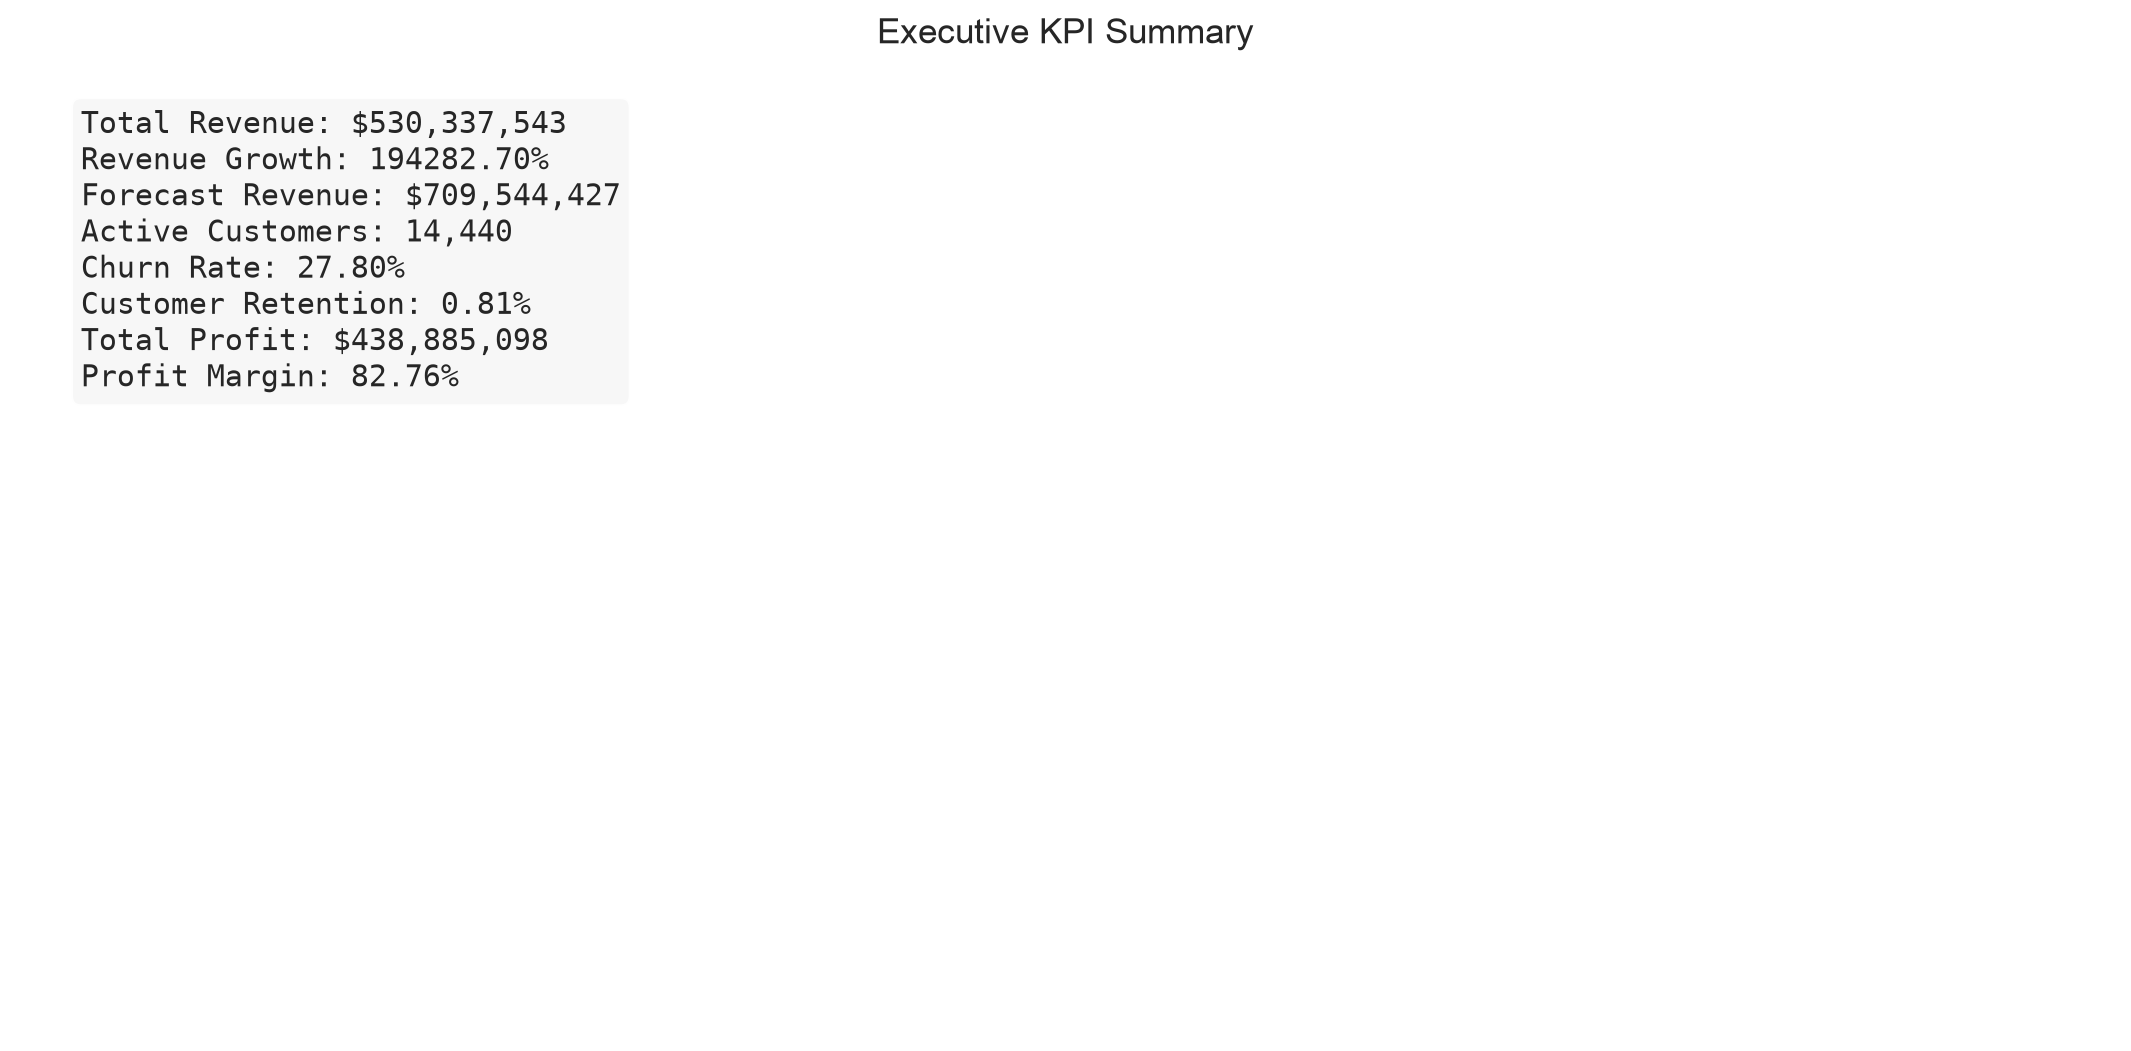

Business insight: revenue and profitability remain strong while churn and retention should be monitored continuously.


In [7]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
ax.axis("off")
summary_text = (
    f"Total Revenue: ${total_revenue:,.0f}\n"
    f"Revenue Growth: {revenue_growth:.2f}%\n"
    f"Forecast Revenue: {'N/A' if pd.isna(forecast_revenue) else f'${forecast_revenue:,.0f}'}\n"
    f"Active Customers: {active_customers:,}\n"
    f"Churn Rate: {'N/A' if pd.isna(churn_rate) else f'{churn_rate:.2f}%'}\n"
    f"Customer Retention: {'N/A' if pd.isna(customer_retention) else f'{customer_retention:.2f}%'}\n"
    f"Total Profit: ${total_profit:,.0f}\n"
    f"Profit Margin: {profit_margin:.2f}%"
)
ax.text(
    0.03,
    0.95,
    summary_text,
    va="top",
    fontsize=12,
    family="monospace",
    bbox={"boxstyle": "round", "facecolor": "#f7f7f7", "alpha": 0.9},
)
ax.set_title("Executive KPI Summary", fontsize=14)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "executive_kpi_summary.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: revenue and profitability remain strong while churn and retention should be monitored continuously.")

## Revenue KPIs

Dashboard-level KPI visualization for revenue kpis.

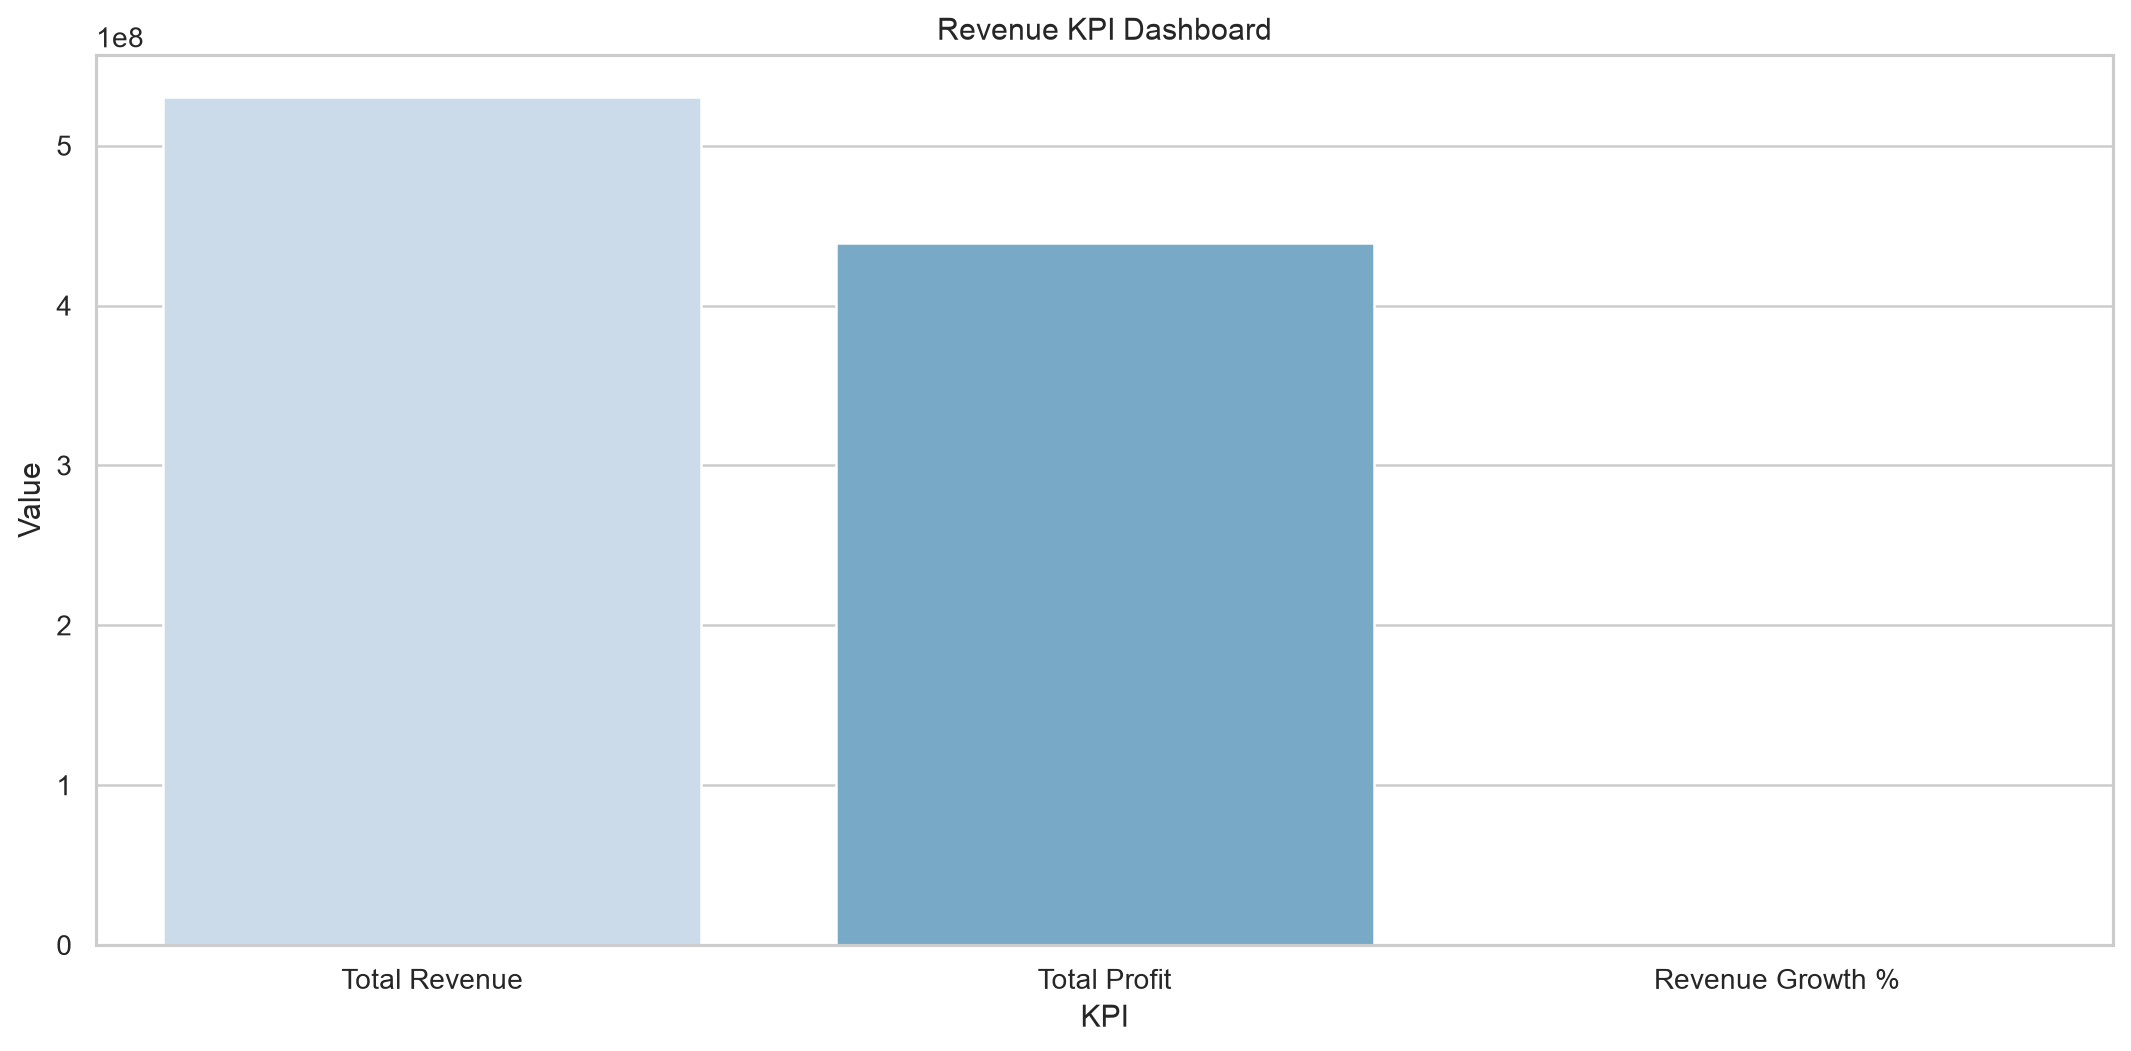

Business insight: core revenue KPIs highlight total value creation and top-line momentum.


In [8]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
revenue_metrics = pd.DataFrame({
    "kpi": ["Total Revenue", "Total Profit", "Revenue Growth %"],
    "value": [total_revenue, total_profit, revenue_growth],
})
sns.barplot(data=revenue_metrics, x="kpi", y="value", palette="Blues", ax=ax)
ax.set_title("Revenue KPI Dashboard")
ax.set_xlabel("KPI")
ax.set_ylabel("Value")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "revenue_kpi_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: core revenue KPIs highlight total value creation and top-line momentum.")

## Customer KPIs

Dashboard-level KPI visualization for customer kpis.

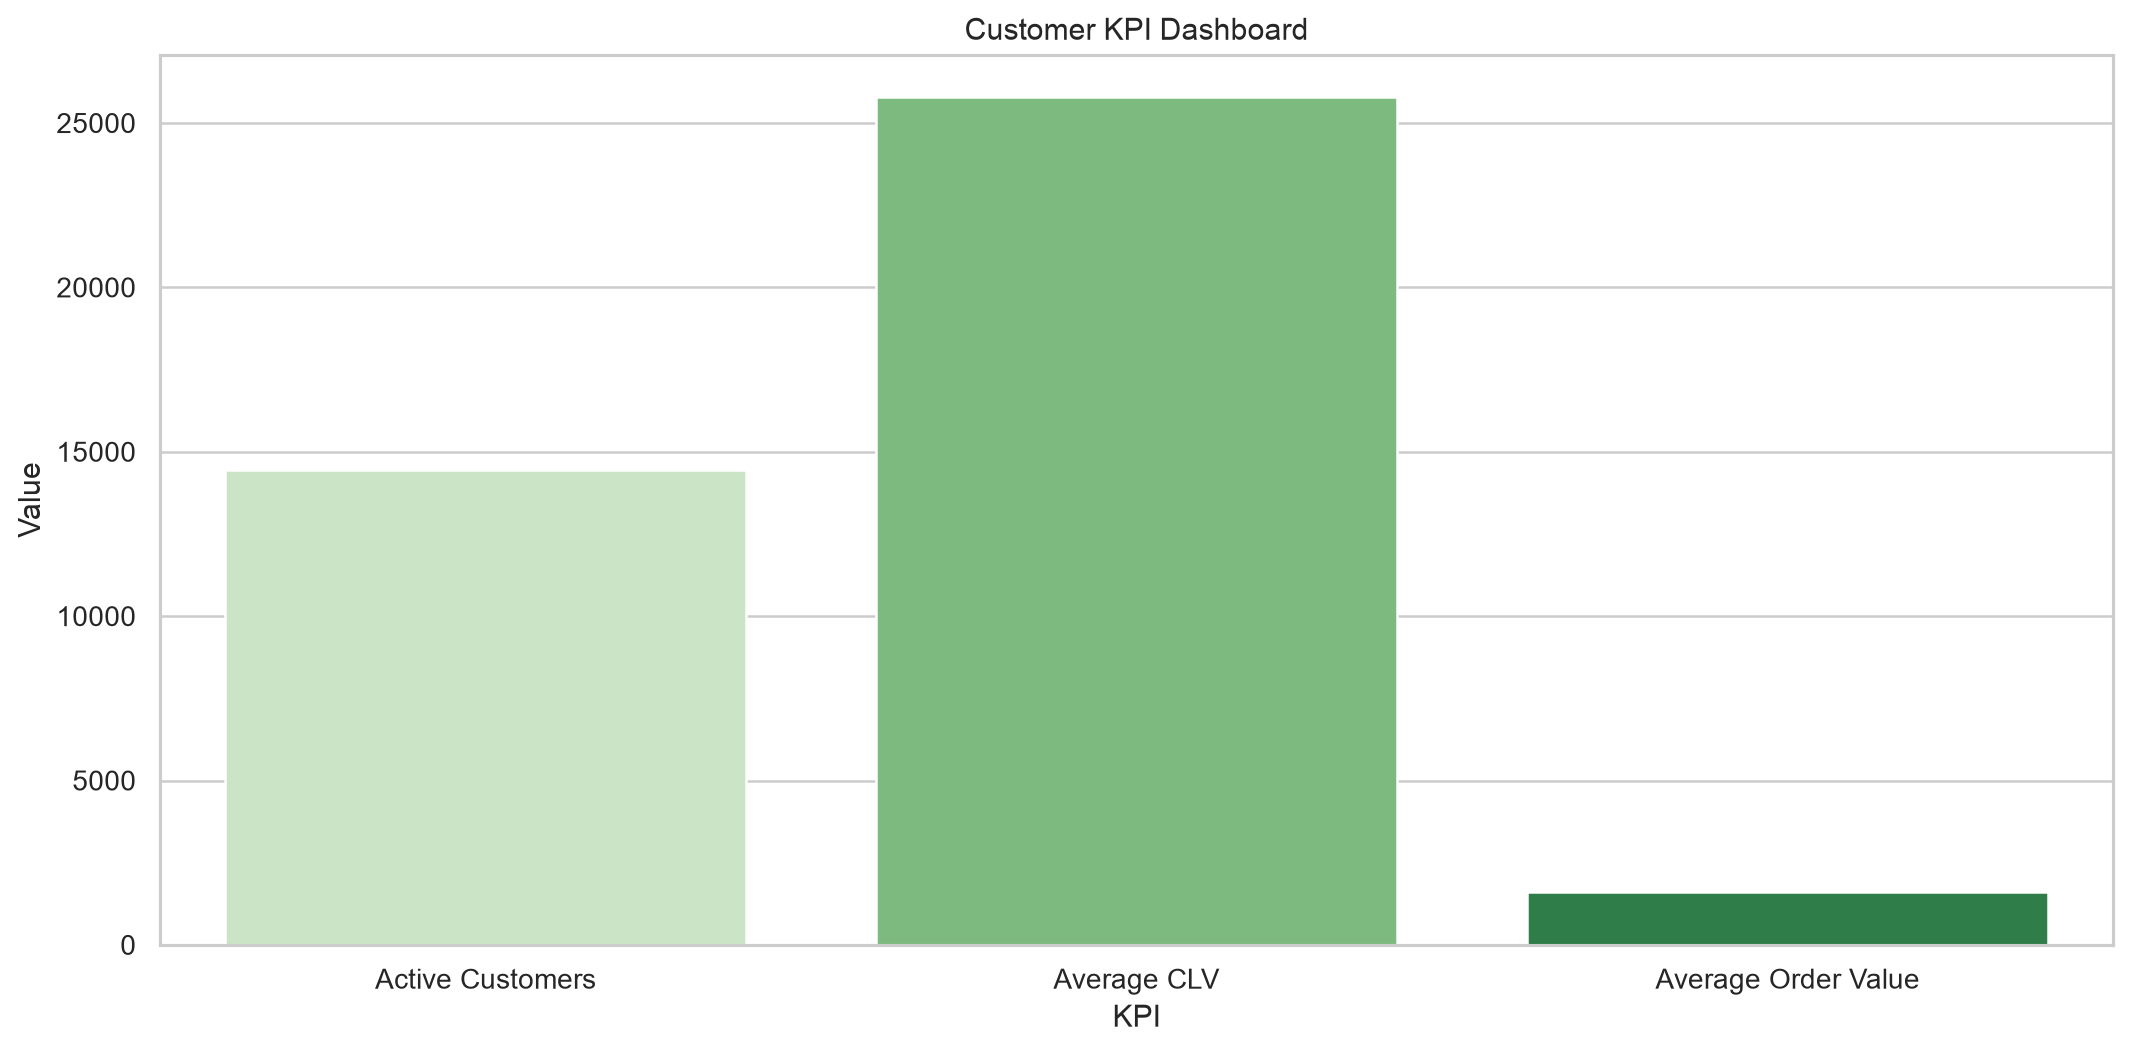

Business insight: customer scale and value KPIs show a broad base with meaningful lifetime value.


In [9]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
customer_metrics = pd.DataFrame({
    "kpi": ["Active Customers", "Average CLV", "Average Order Value"],
    "value": [active_customers, average_clv if not pd.isna(average_clv) else 0, average_order_value if not pd.isna(average_order_value) else 0],
})
sns.barplot(data=customer_metrics, x="kpi", y="value", palette="Greens", ax=ax)
ax.set_title("Customer KPI Dashboard")
ax.set_xlabel("KPI")
ax.set_ylabel("Value")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "customer_kpi_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: customer scale and value KPIs show a broad base with meaningful lifetime value.")

## Forecast KPI Dashboard

Dashboard-level KPI visualization for forecast kpi dashboard.

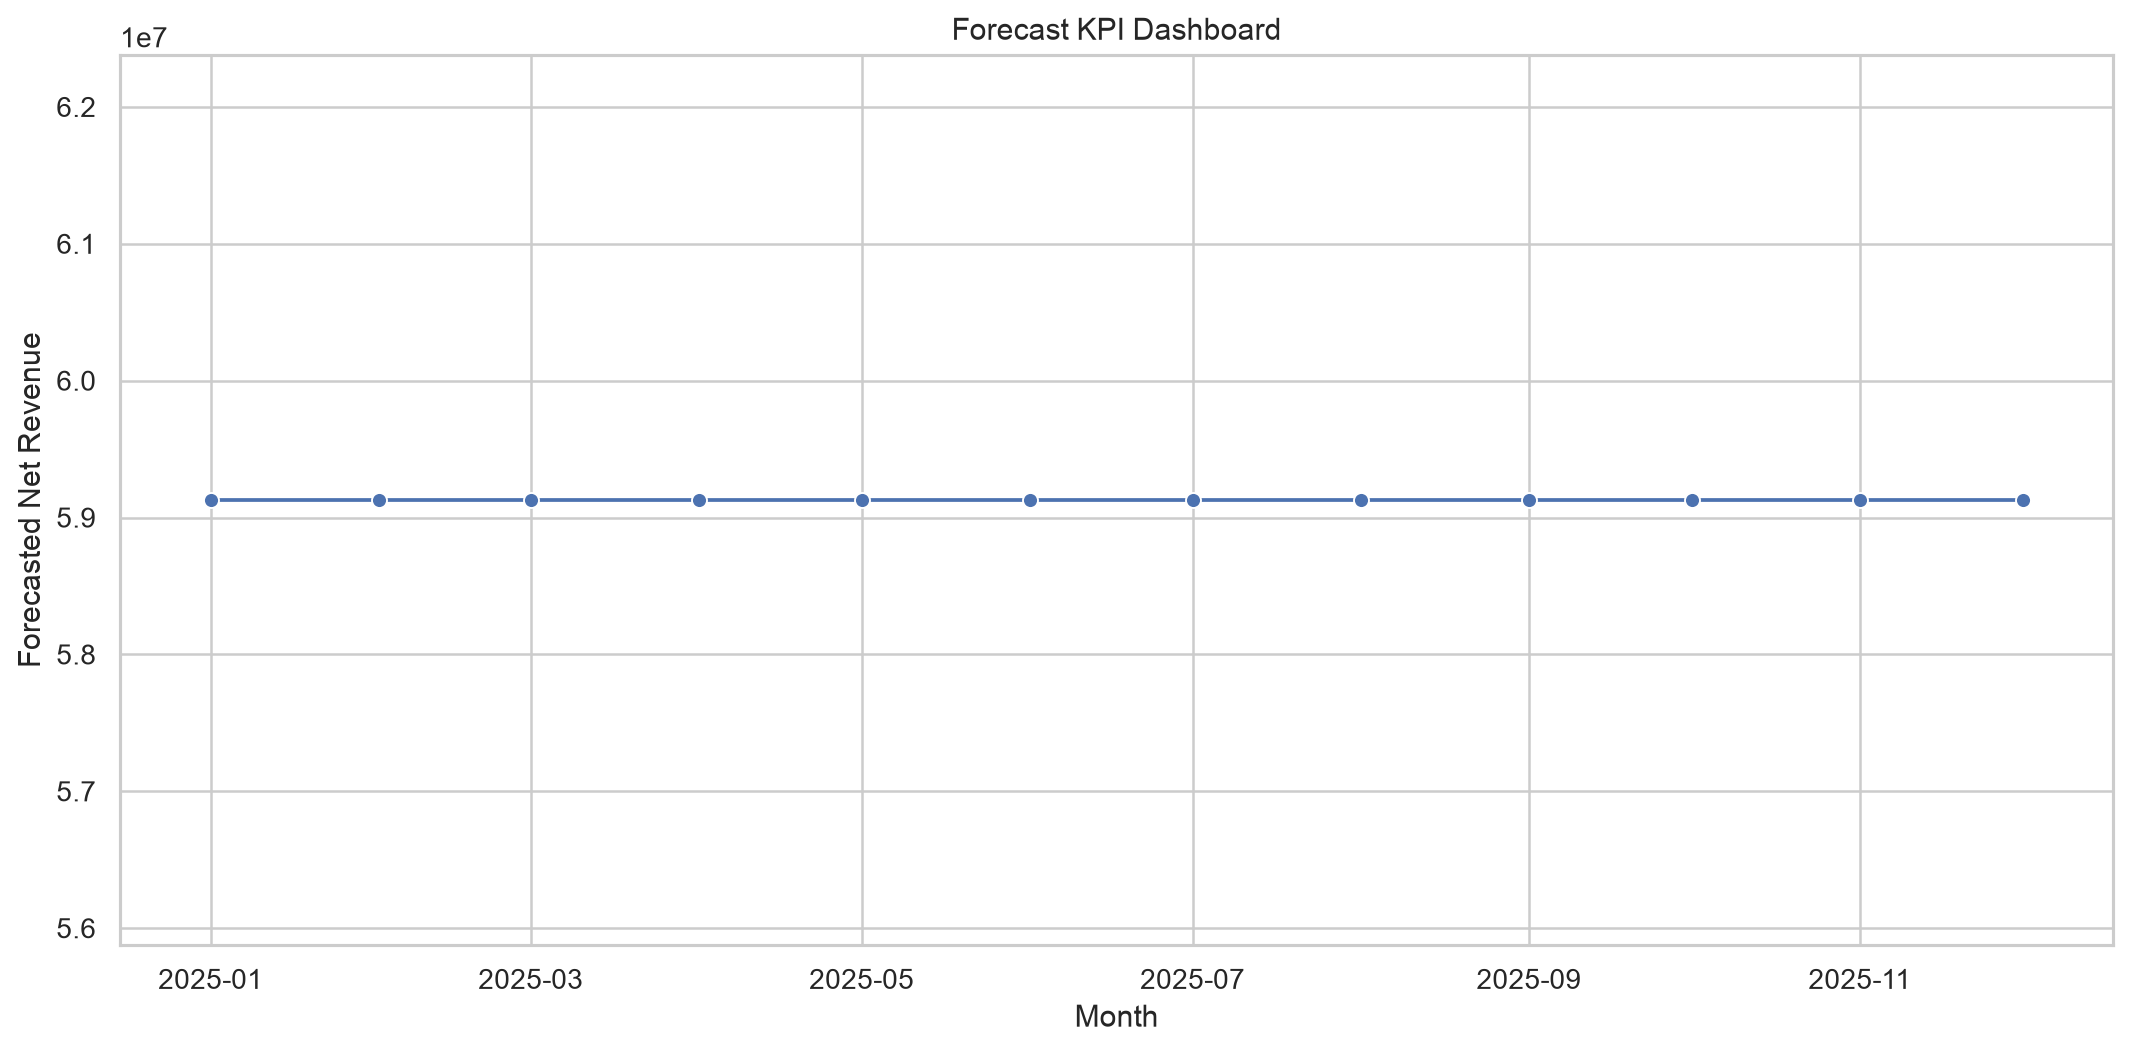

Business insight: forecast KPIs provide a forward-looking revenue baseline when forecast output is available.


In [10]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
if forecast_df is not None and "year_month" in forecast_df.columns and "forecasted_net_revenue" in forecast_df.columns:
    fdf = forecast_df.copy()
    fdf["year_month"] = pd.to_datetime(fdf["year_month"], errors="coerce")
    sns.lineplot(data=fdf, x="year_month", y="forecasted_net_revenue", marker="o", ax=ax)
    ax.set_title("Forecast KPI Dashboard")
    ax.set_xlabel("Month")
    ax.set_ylabel("Forecasted Net Revenue")
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "Forecast output unavailable", ha="center", va="center", fontsize=12)
    ax.set_title("Forecast KPI Dashboard")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "forecast_kpi_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: forecast KPIs provide a forward-looking revenue baseline when forecast output is available.")

## Churn KPIs

Dashboard-level KPI visualization for churn kpis.

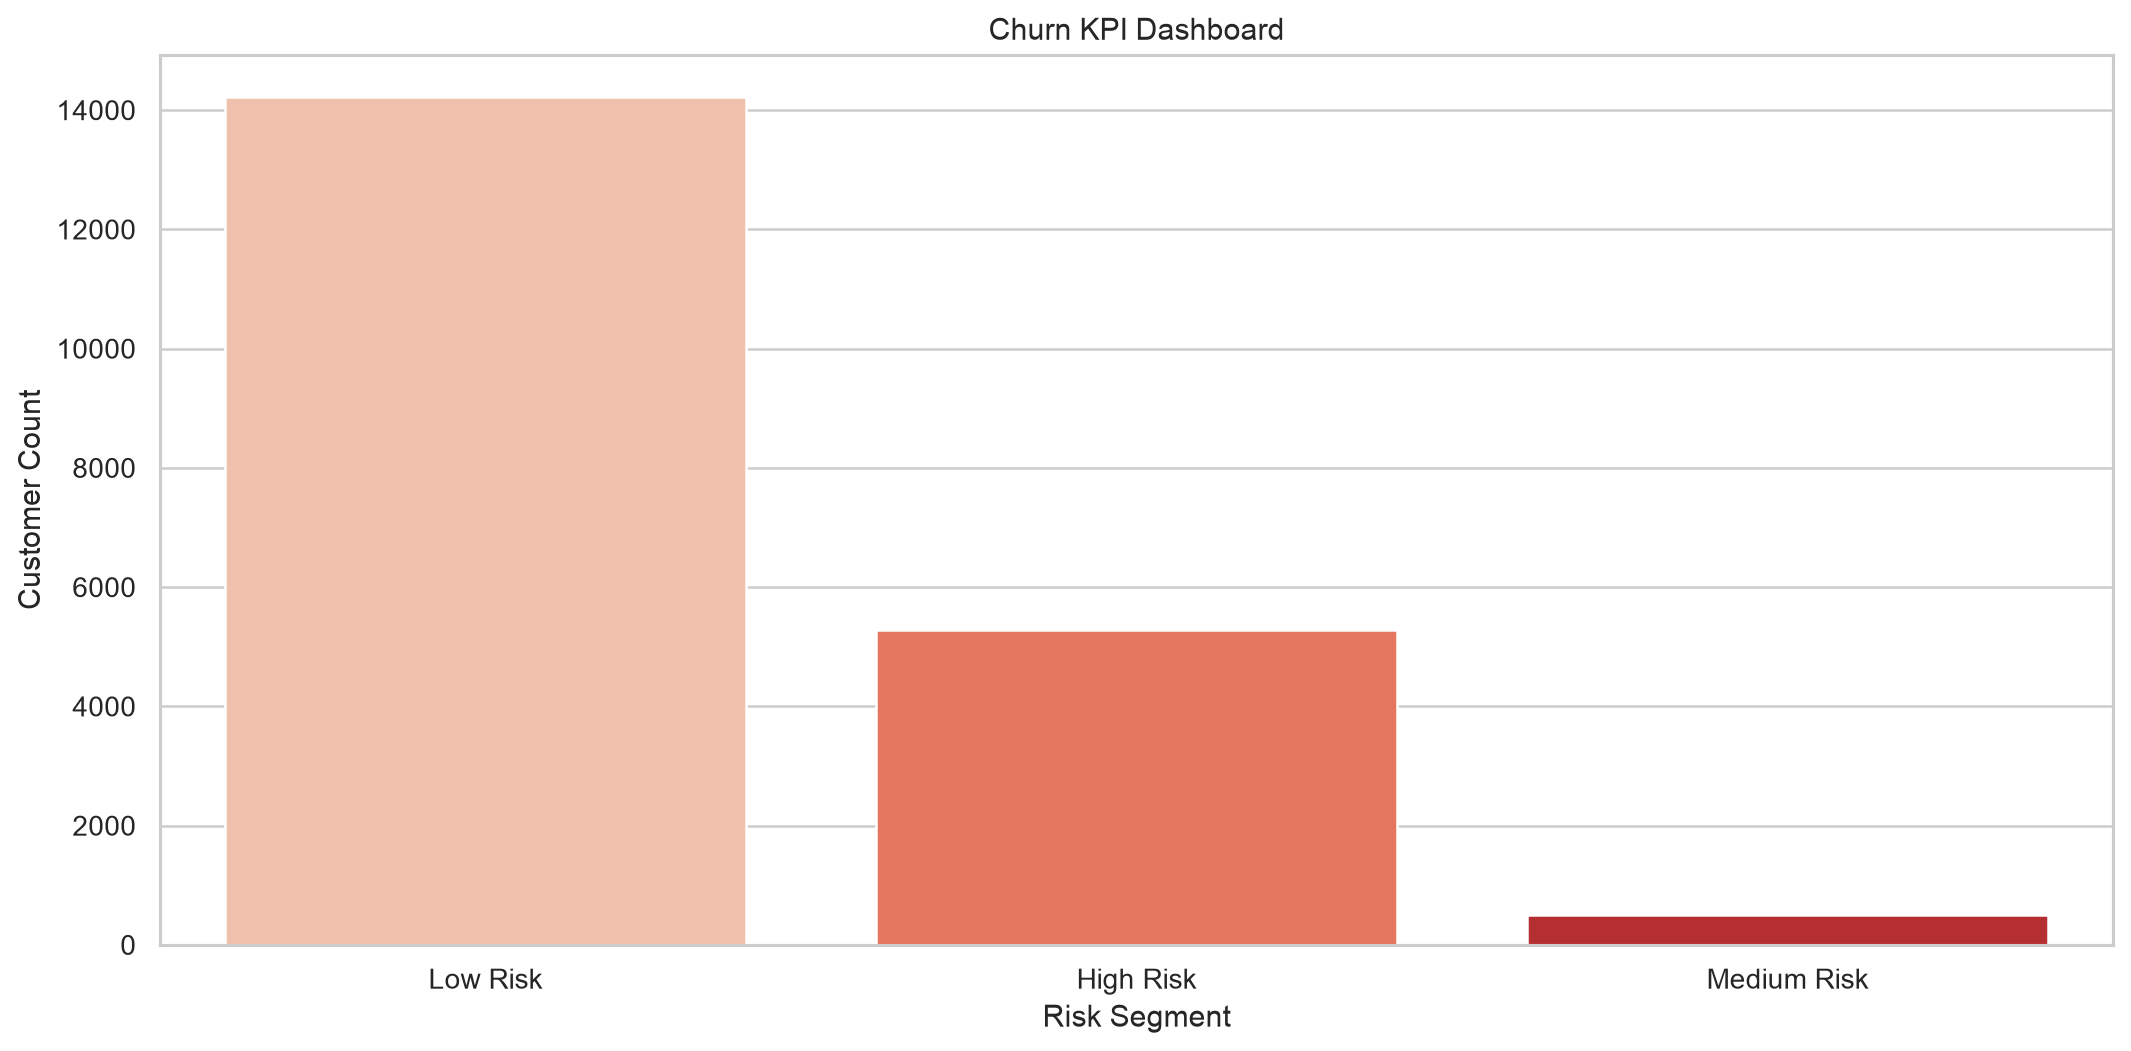

Business insight: churn KPI distribution helps prioritize intervention by risk tier.


In [11]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
churn_preds = outputs_data.get("churn_predictions")
if churn_preds is not None and "risk_segment" in churn_preds.columns:
    order = churn_preds["risk_segment"].value_counts().index
    sns.countplot(data=churn_preds, x="risk_segment", order=order, palette="Reds", ax=ax)
    ax.set_title("Churn KPI Dashboard")
    ax.set_xlabel("Risk Segment")
    ax.set_ylabel("Customer Count")
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "Churn outputs unavailable", ha="center", va="center", fontsize=12)
    ax.set_title("Churn KPI Dashboard")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "churn_kpi_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: churn KPI distribution helps prioritize intervention by risk tier.")

## Cohort KPIs

Dashboard-level KPI visualization for cohort kpis.

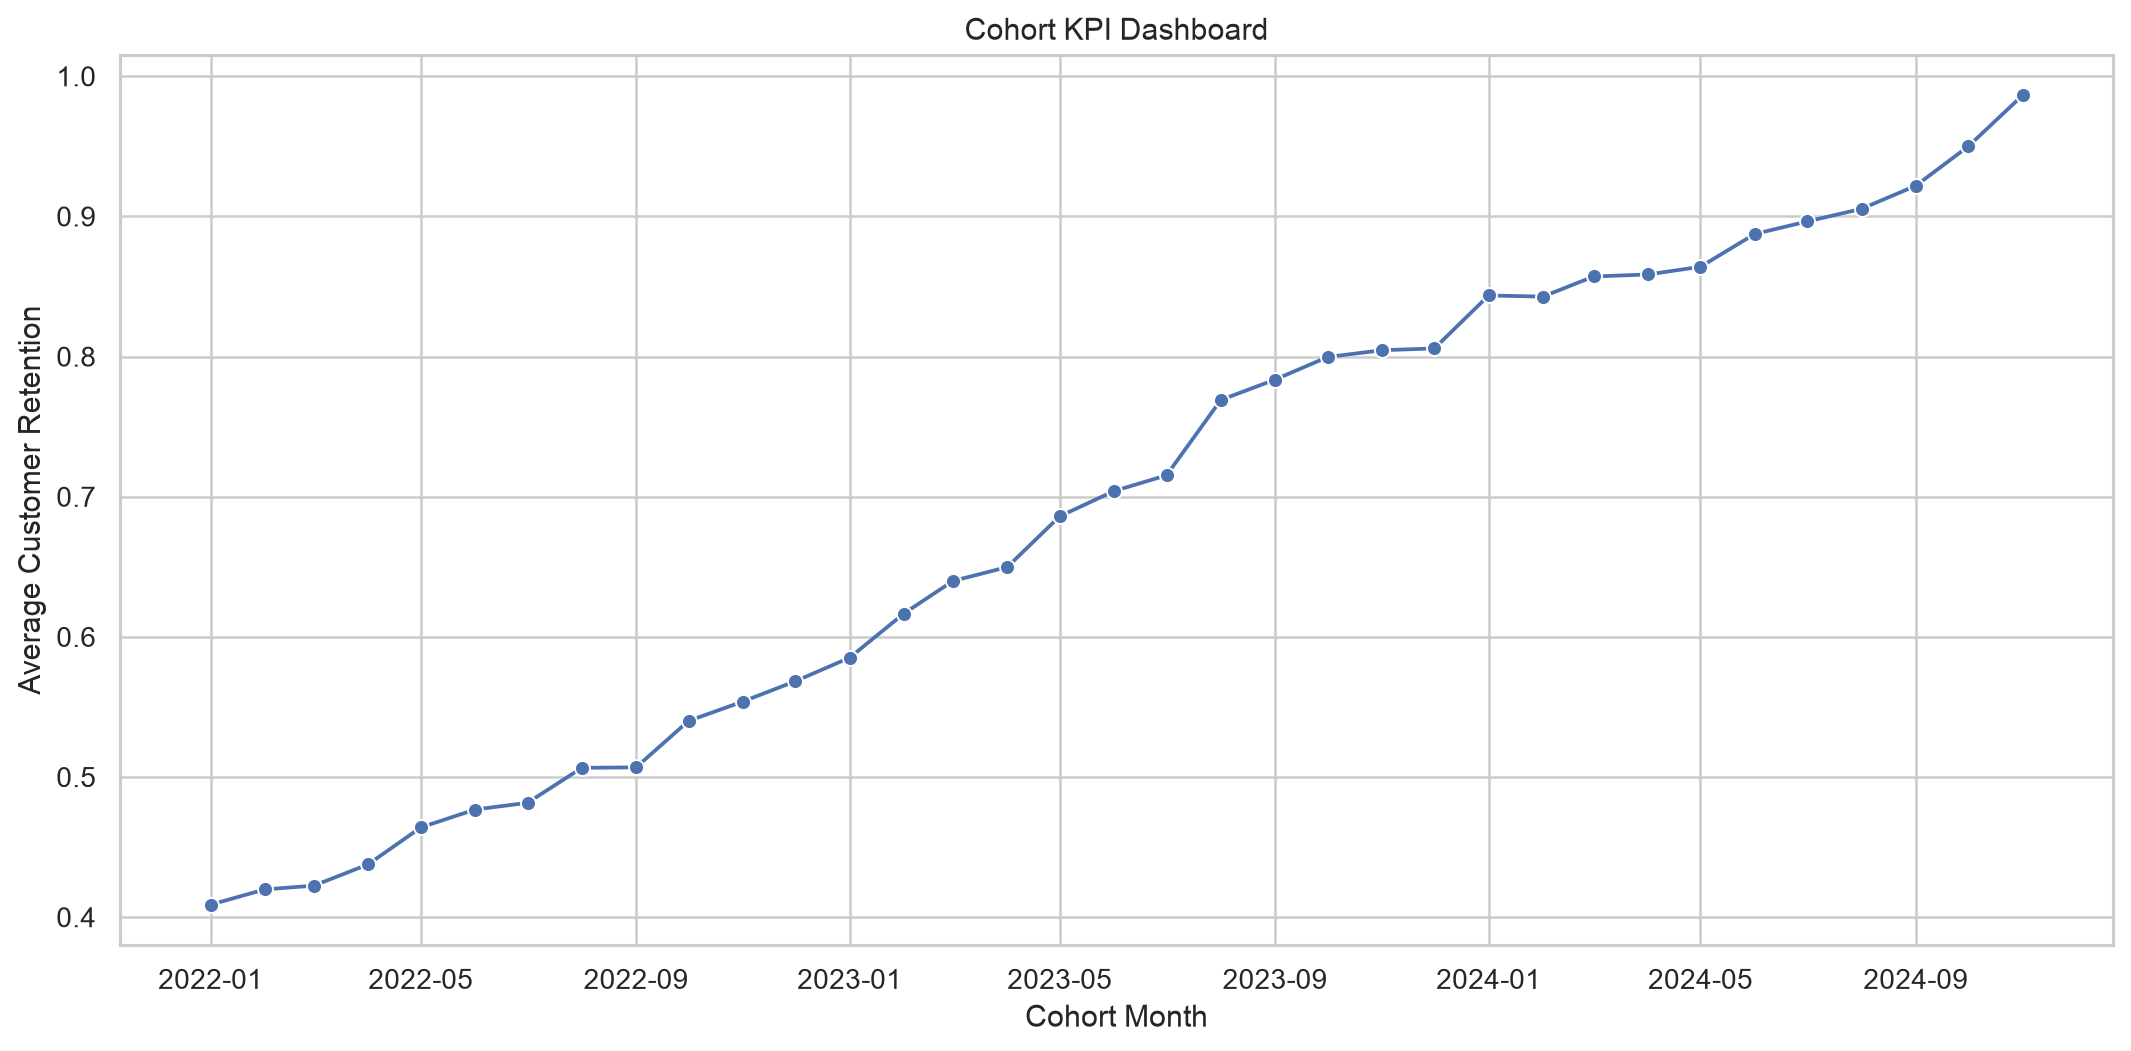

Business insight: cohort KPIs reveal retention strength and decay patterns by signup month.


In [12]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
cohort_df = outputs_data.get("cohort_summary")
if cohort_df is not None and "cohort_month" in cohort_df.columns and "average_customer_retention" in cohort_df.columns:
    cdf = cohort_df.copy()
    cdf["cohort_month"] = pd.to_datetime(cdf["cohort_month"], errors="coerce")
    sns.lineplot(data=cdf.sort_values("cohort_month"), x="cohort_month", y="average_customer_retention", marker="o", ax=ax)
    ax.set_title("Cohort KPI Dashboard")
    ax.set_xlabel("Cohort Month")
    ax.set_ylabel("Average Customer Retention")
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "Cohort outputs unavailable", ha="center", va="center", fontsize=12)
    ax.set_title("Cohort KPI Dashboard")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "cohort_kpi_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: cohort KPIs reveal retention strength and decay patterns by signup month.")

## RFM KPIs

Dashboard-level KPI visualization for rfm kpis.

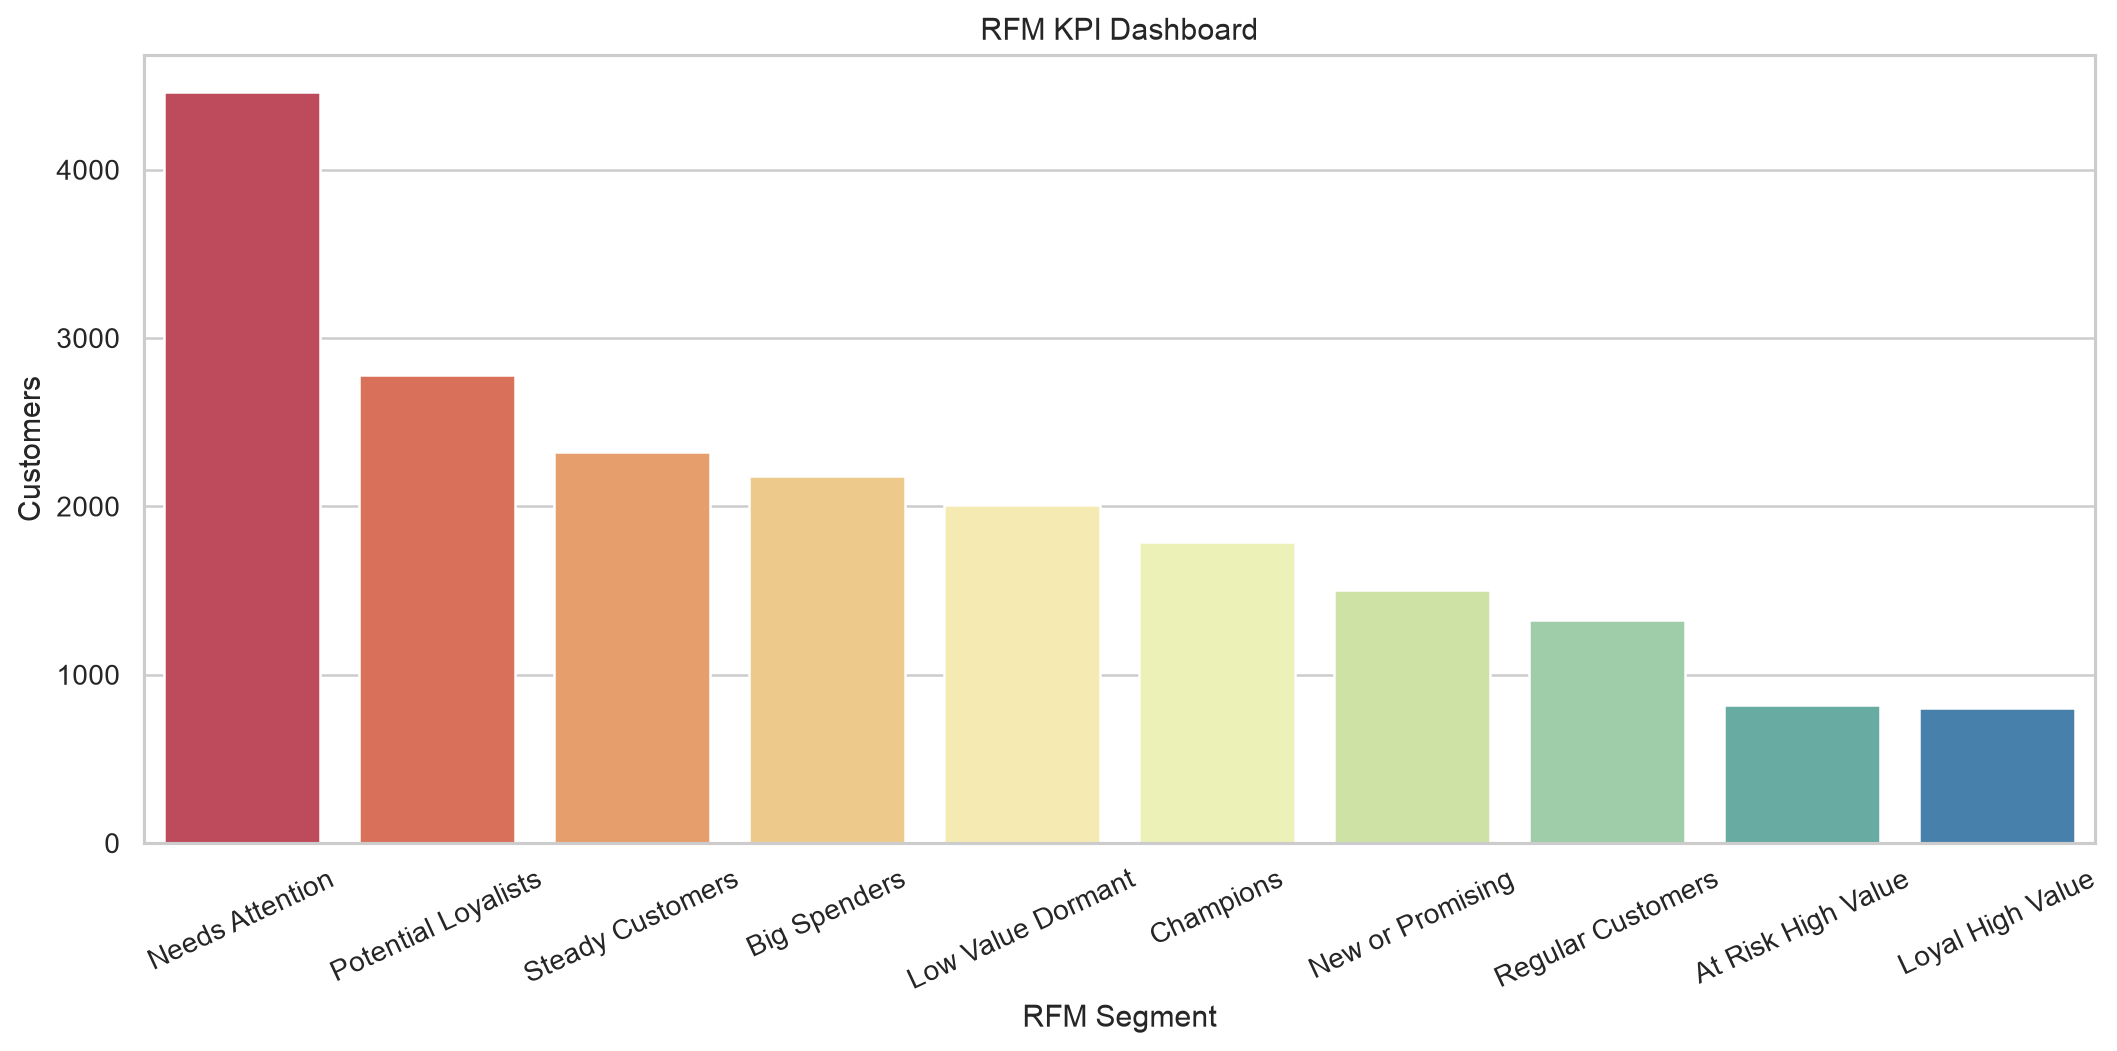

Business insight: RFM segments identify concentration of highly engaged and low-value customer groups.


In [13]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
rfm_seg = outputs_data.get("segment_summary")
if rfm_seg is not None and "rfm_segment" in rfm_seg.columns and "customers" in rfm_seg.columns:
    top_rfm = rfm_seg.sort_values("customers", ascending=False).head(10)
    sns.barplot(data=top_rfm, x="rfm_segment", y="customers", palette="Spectral", ax=ax)
    ax.set_title("RFM KPI Dashboard")
    ax.set_xlabel("RFM Segment")
    ax.set_ylabel("Customers")
    ax.tick_params(axis="x", rotation=25)
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "RFM outputs unavailable", ha="center", va="center", fontsize=12)
    ax.set_title("RFM KPI Dashboard")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "rfm_kpi_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: RFM segments identify concentration of highly engaged and low-value customer groups.")

## Profitability KPIs

Dashboard-level KPI visualization for profitability kpis.

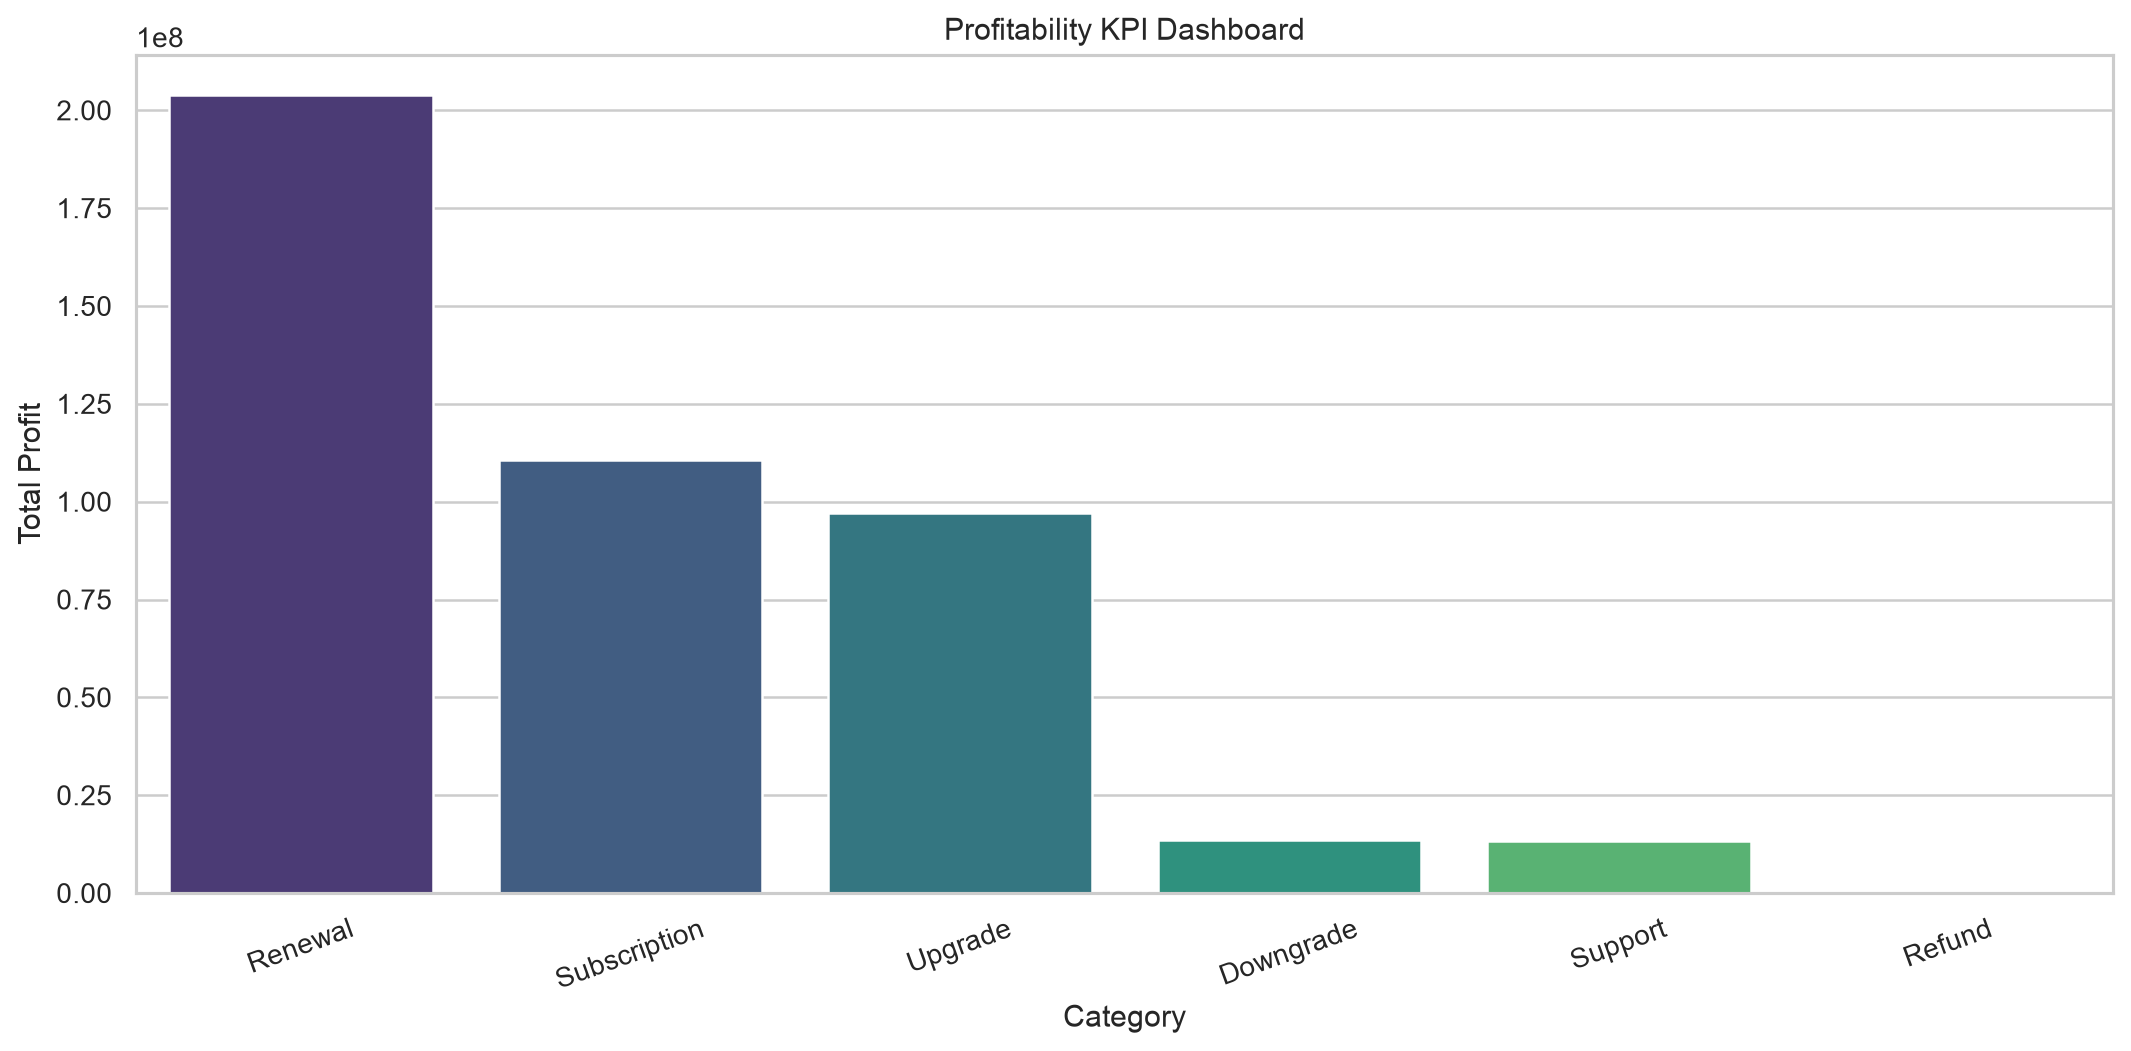

Business insight: profitability KPIs expose where margin and category contribution are strongest.


In [14]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
prod_prof = outputs_data.get("product_profitability")
if prod_prof is not None and "transaction_category" in prod_prof.columns and "total_profit" in prod_prof.columns:
    top_prod = prod_prof.sort_values("total_profit", ascending=False)
    sns.barplot(data=top_prod, x="transaction_category", y="total_profit", palette="viridis", ax=ax)
    ax.set_title("Profitability KPI Dashboard")
    ax.set_xlabel("Category")
    ax.set_ylabel("Total Profit")
    ax.tick_params(axis="x", rotation=20)
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "Profitability outputs unavailable", ha="center", va="center", fontsize=12)
    ax.set_title("Profitability KPI Dashboard")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "profitability_kpi_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: profitability KPIs expose where margin and category contribution are strongest.")

## Executive Scorecards

A compact multi-panel scorecard combines high-priority metrics on one figure for executive scanning.

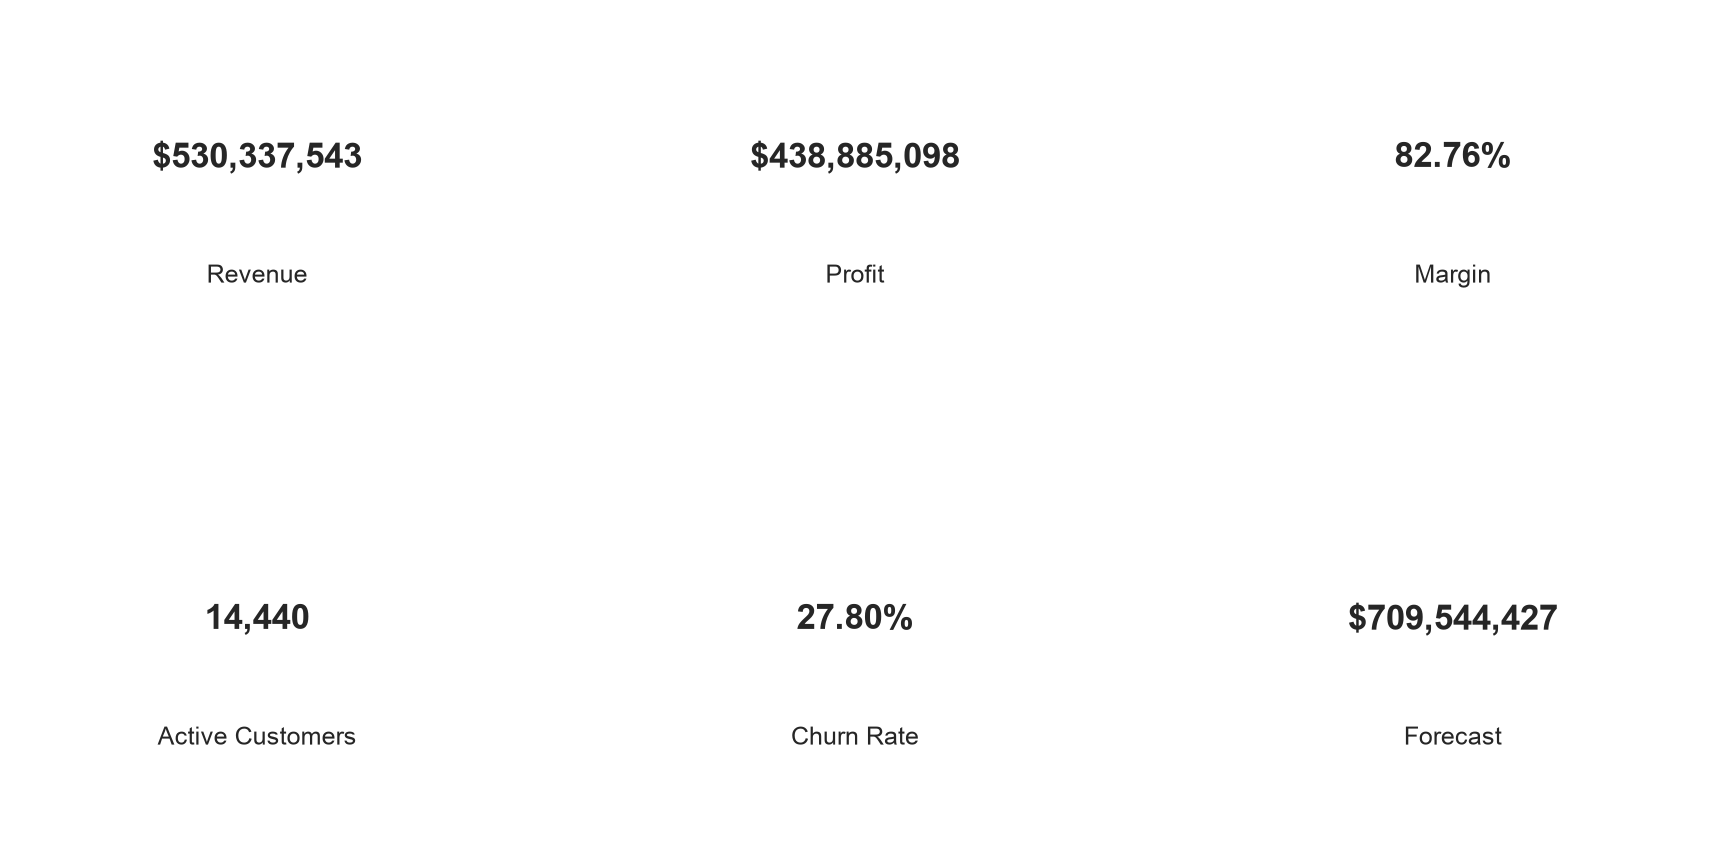

Business insight: scorecards provide a concise snapshot of top-line performance and customer risk.


In [15]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
fig.clf()
gs = GridSpec(2, 3, figure=fig, hspace=0.25, wspace=0.25)
cards = [
    ("Revenue", f"${total_revenue:,.0f}"),
    ("Profit", f"${total_profit:,.0f}"),
    ("Margin", f"{profit_margin:.2f}%"),
    ("Active Customers", f"{active_customers:,}"),
    ("Churn Rate", "N/A" if pd.isna(churn_rate) else f"{churn_rate:.2f}%"),
    ("Forecast", "N/A" if pd.isna(forecast_revenue) else f"${forecast_revenue:,.0f}"),
]
for i, (label, value) in enumerate(cards):
    r, c = divmod(i, 3)
    axi = fig.add_subplot(gs[r, c])
    axi.axis("off")
    axi.text(0.5, 0.62, value, ha="center", va="center", fontsize=14, fontweight="bold")
    axi.text(0.5, 0.30, label, ha="center", va="center", fontsize=10)
    for spine in axi.spines.values():
        spine.set_visible(True)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "executive_scorecards.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: scorecards provide a concise snapshot of top-line performance and customer risk.")

## Revenue Trend Dashboard

Executive view for revenue trend dashboard.

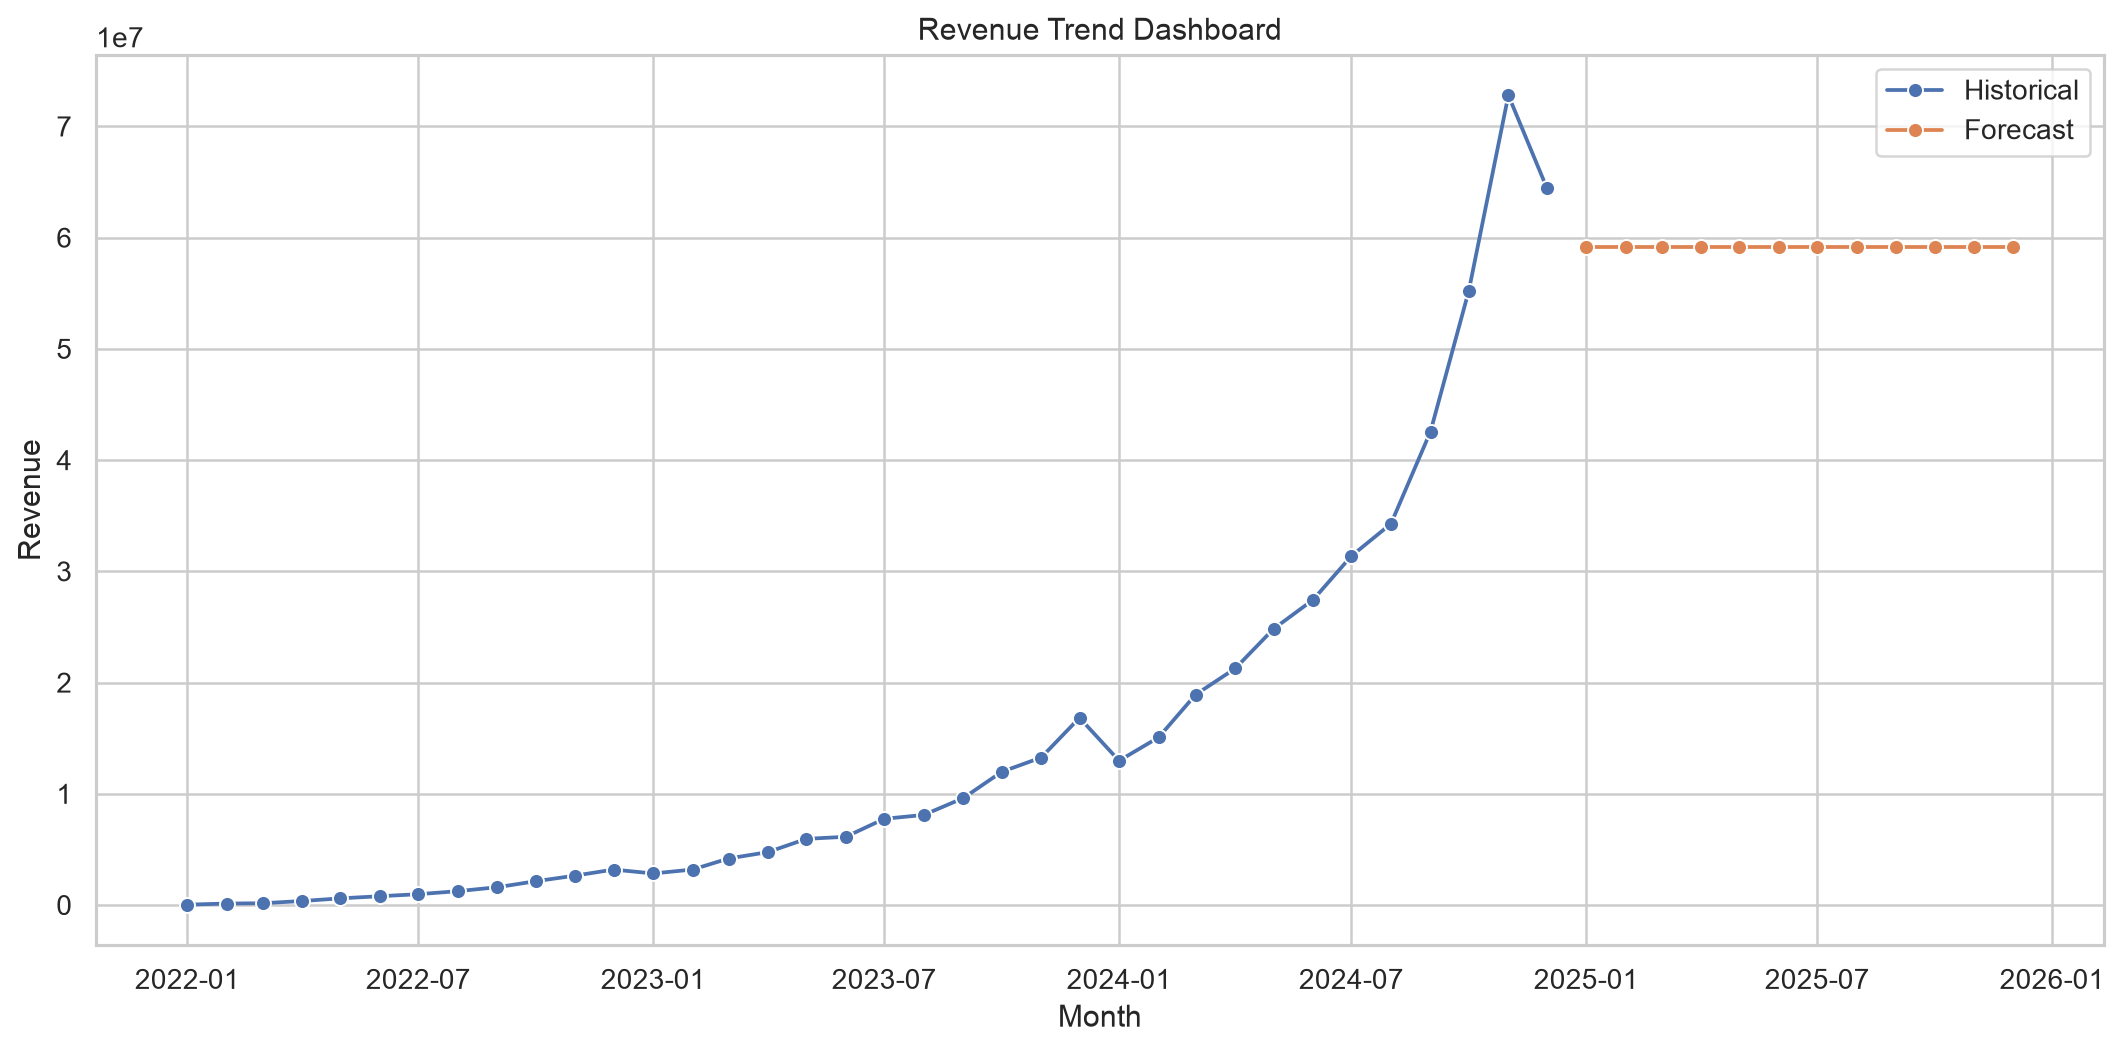

Business insight: revenue trend dashboard combines realized and forecasted trajectories for planning visibility.


In [16]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
mrev = monthly_revenue.copy()
mrev["year_month"] = pd.to_datetime(mrev["year_month"], errors="coerce")
sns.lineplot(data=mrev.sort_values("year_month"), x="year_month", y="net_revenue", marker="o", ax=ax, label="Historical")
if forecast_df is not None and "year_month" in forecast_df.columns and "forecasted_net_revenue" in forecast_df.columns:
    fdf = forecast_df.copy()
    fdf["year_month"] = pd.to_datetime(fdf["year_month"], errors="coerce")
    sns.lineplot(data=fdf.sort_values("year_month"), x="year_month", y="forecasted_net_revenue", marker="o", ax=ax, label="Forecast")
ax.set_title("Revenue Trend Dashboard")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "revenue_trend_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: revenue trend dashboard combines realized and forecasted trajectories for planning visibility.")

## Customer Dashboard

Executive view for customer dashboard.

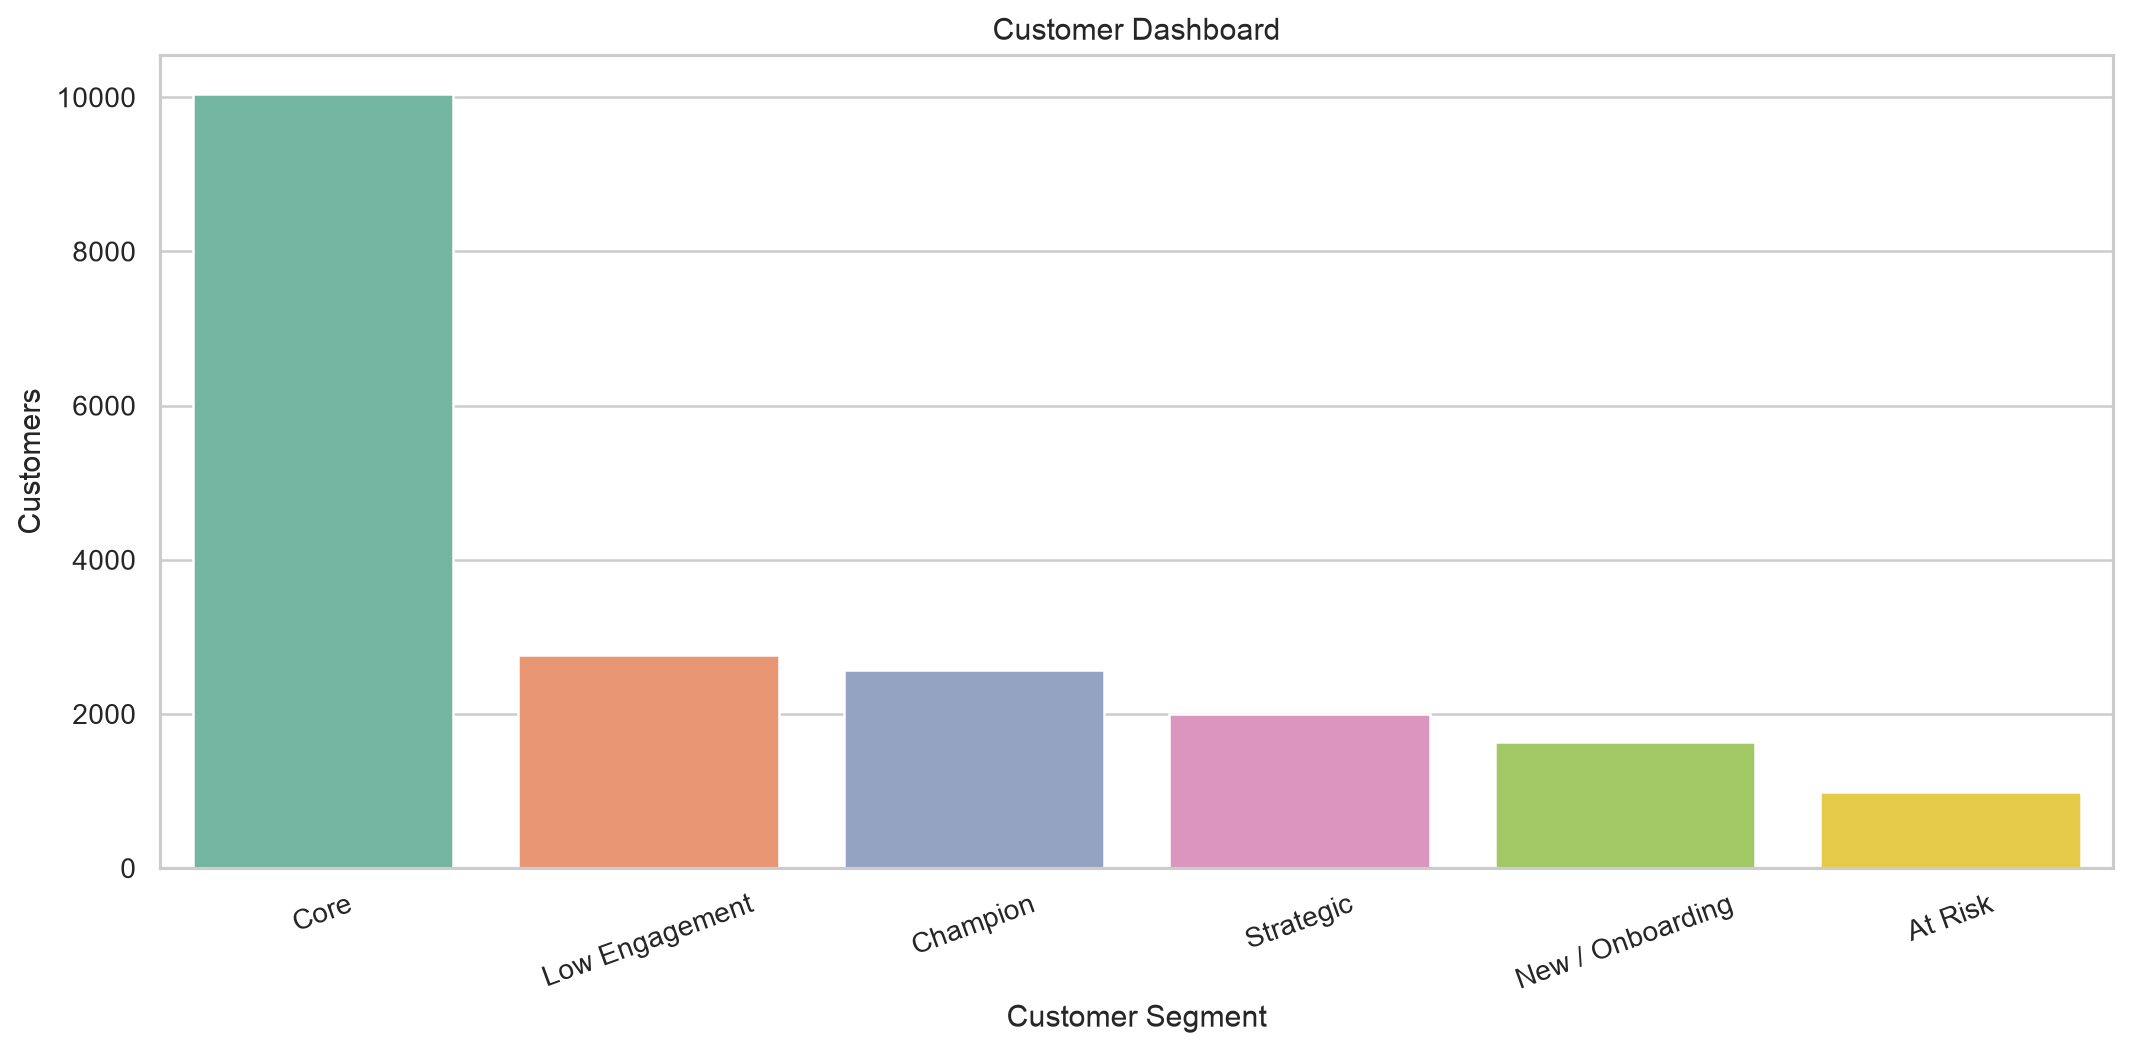

Business insight: customer dashboard highlights concentration of the largest customer segments.


In [17]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
if "customer_segment" in customers.columns:
    top_segments = customers["customer_segment"].value_counts().head(10).reset_index()
    top_segments.columns = ["customer_segment", "count"]
    sns.barplot(data=top_segments, x="customer_segment", y="count", palette="Set2", ax=ax)
    ax.set_title("Customer Dashboard")
    ax.set_xlabel("Customer Segment")
    ax.set_ylabel("Customers")
    ax.tick_params(axis="x", rotation=20)
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "Customer segment field unavailable", ha="center", va="center")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "customer_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: customer dashboard highlights concentration of the largest customer segments.")

## Churn Dashboard

Executive view for churn dashboard.

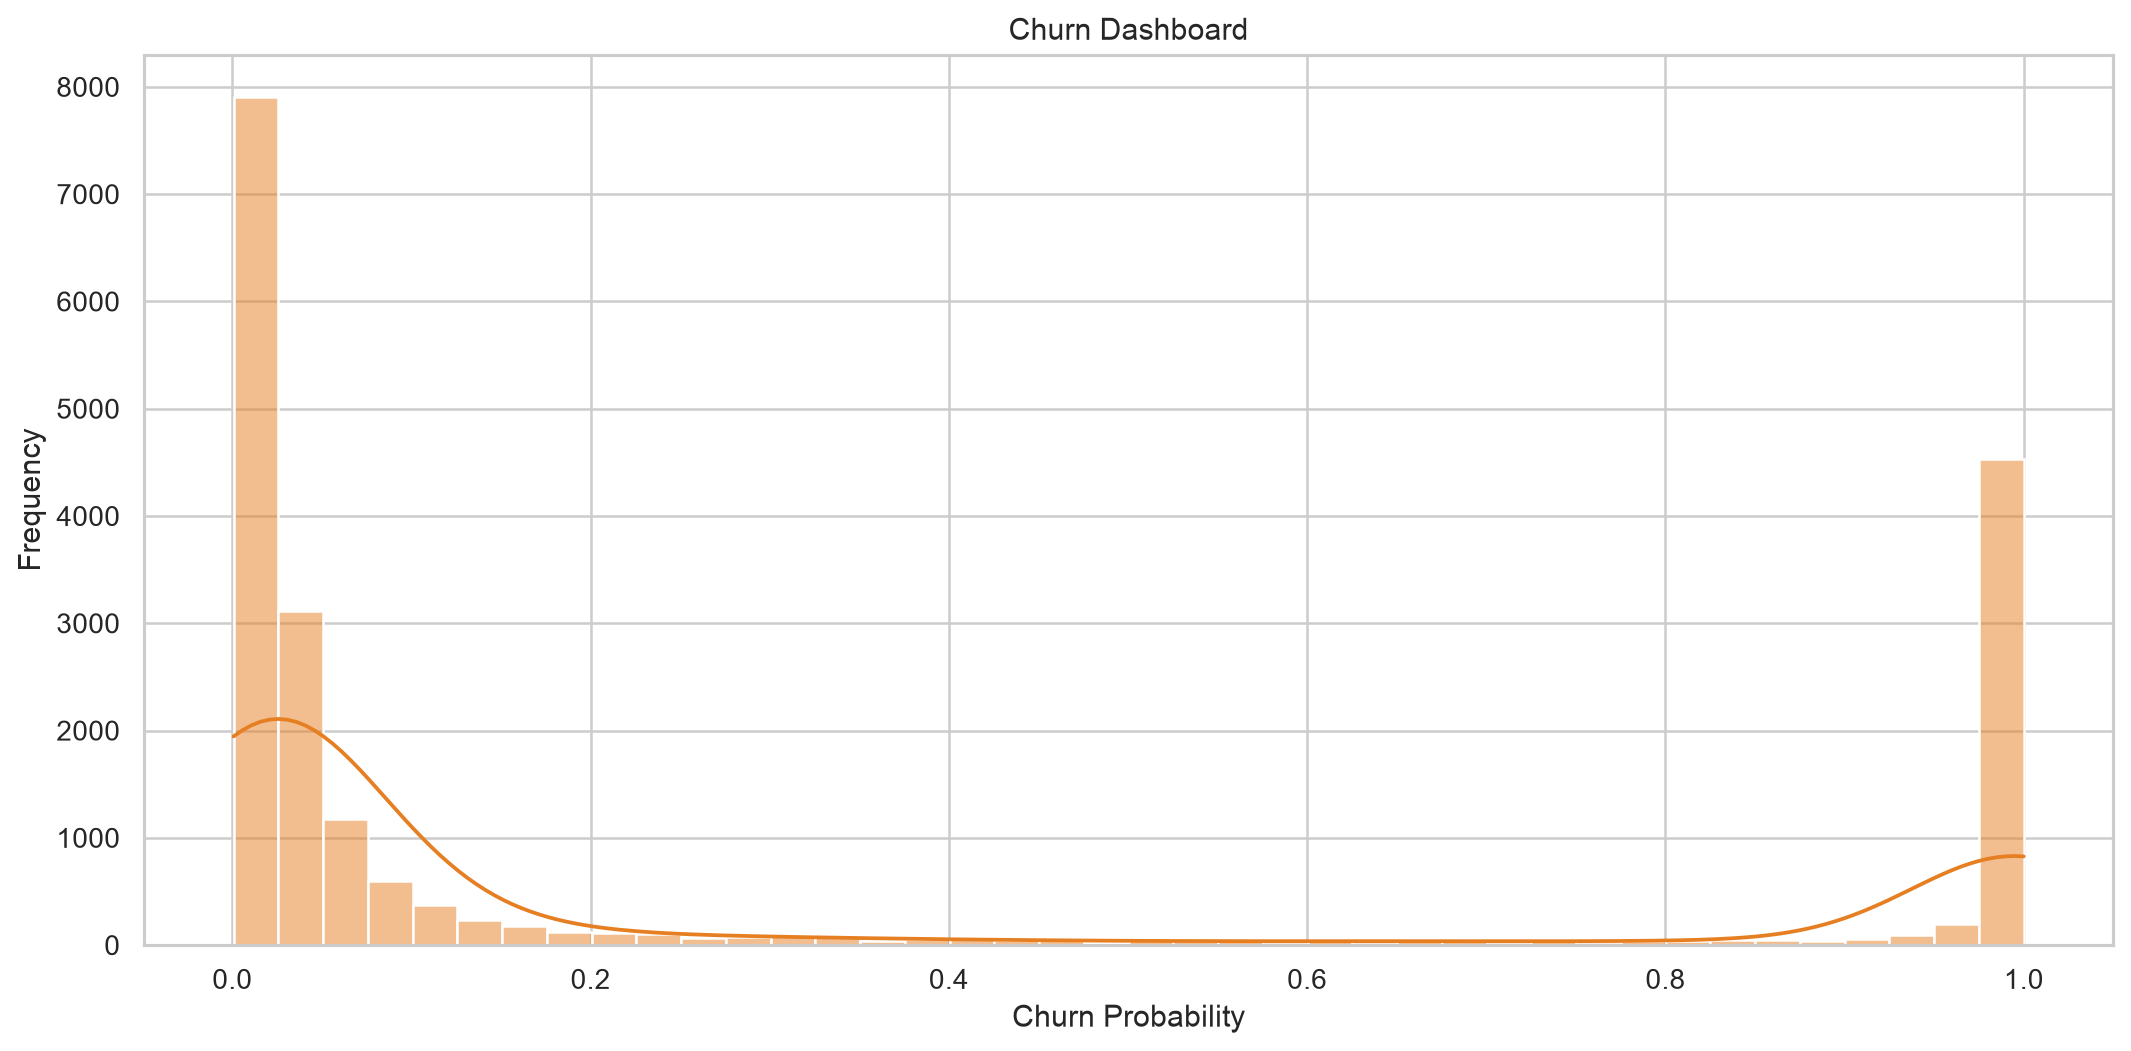

Business insight: churn probability distribution indicates the size of the high-risk customer pool.


In [18]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
if outputs_data.get("churn_predictions") is not None and "churn_probability" in outputs_data["churn_predictions"].columns:
    sns.histplot(outputs_data["churn_predictions"]["churn_probability"], bins=40, kde=True, color="#e67e22", ax=ax)
    ax.set_title("Churn Dashboard")
    ax.set_xlabel("Churn Probability")
    ax.set_ylabel("Frequency")
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "Churn predictions unavailable", ha="center", va="center")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "churn_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: churn probability distribution indicates the size of the high-risk customer pool.")

## Cohort Dashboard

Executive view for cohort dashboard.

2026-07-11 12:46:37,202 - INFO - Loaded customer_retention_matrix.csv with shape (35, 37)


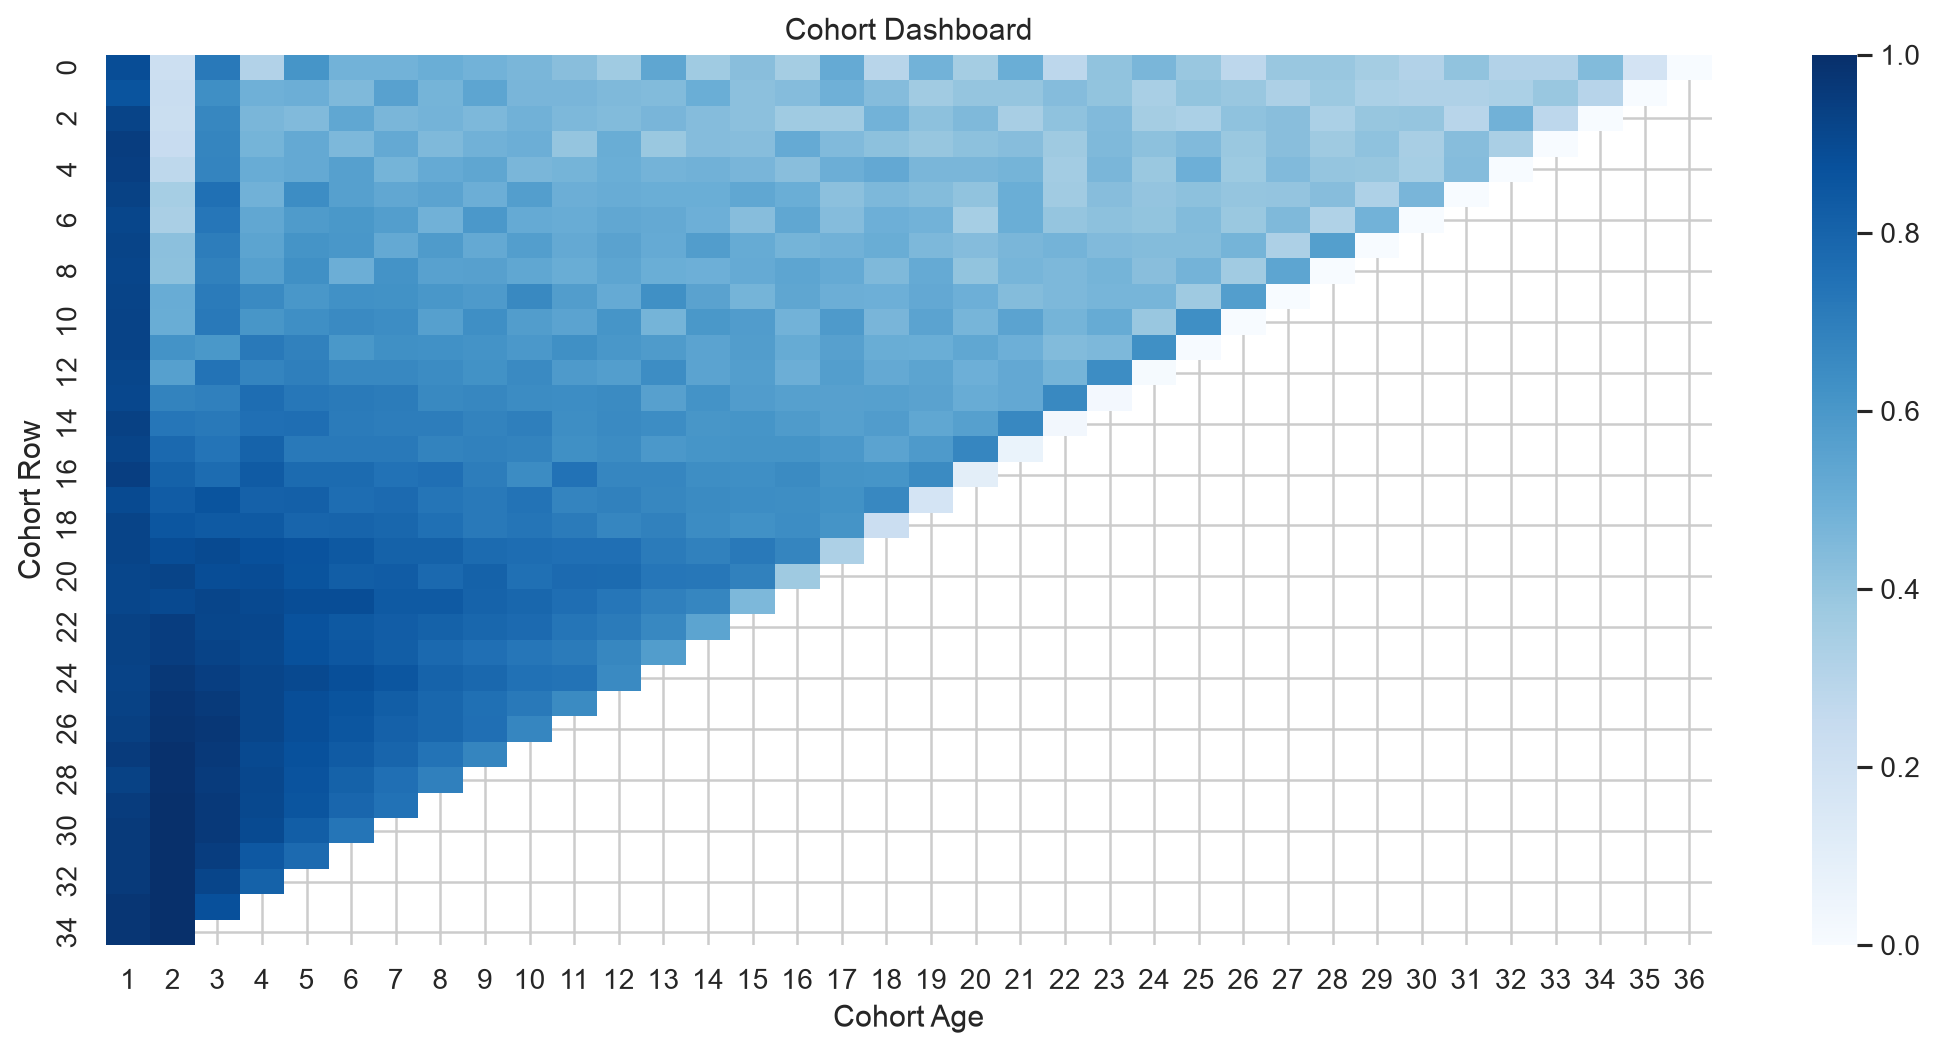

Business insight: cohort heatmap visualizes retention consistency and drop-off dynamics over cohort age.


In [19]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
retention_matrix = outputs_data.get("customer_retention_matrix")
if retention_matrix is None:
    retention_matrix = safe_read_csv(OUTPUT_DIR / "customer_retention_matrix.csv")
if retention_matrix is not None:
    heat = retention_matrix.drop(columns=["cohort_month"], errors="ignore").apply(pd.to_numeric, errors="coerce")
    sns.heatmap(heat, cmap="Blues", cbar=True, ax=ax)
    ax.set_title("Cohort Dashboard")
    ax.set_xlabel("Cohort Age")
    ax.set_ylabel("Cohort Row")
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "Cohort matrix unavailable", ha="center", va="center")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "cohort_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: cohort heatmap visualizes retention consistency and drop-off dynamics over cohort age.")

## RFM Dashboard

Executive view for rfm dashboard.

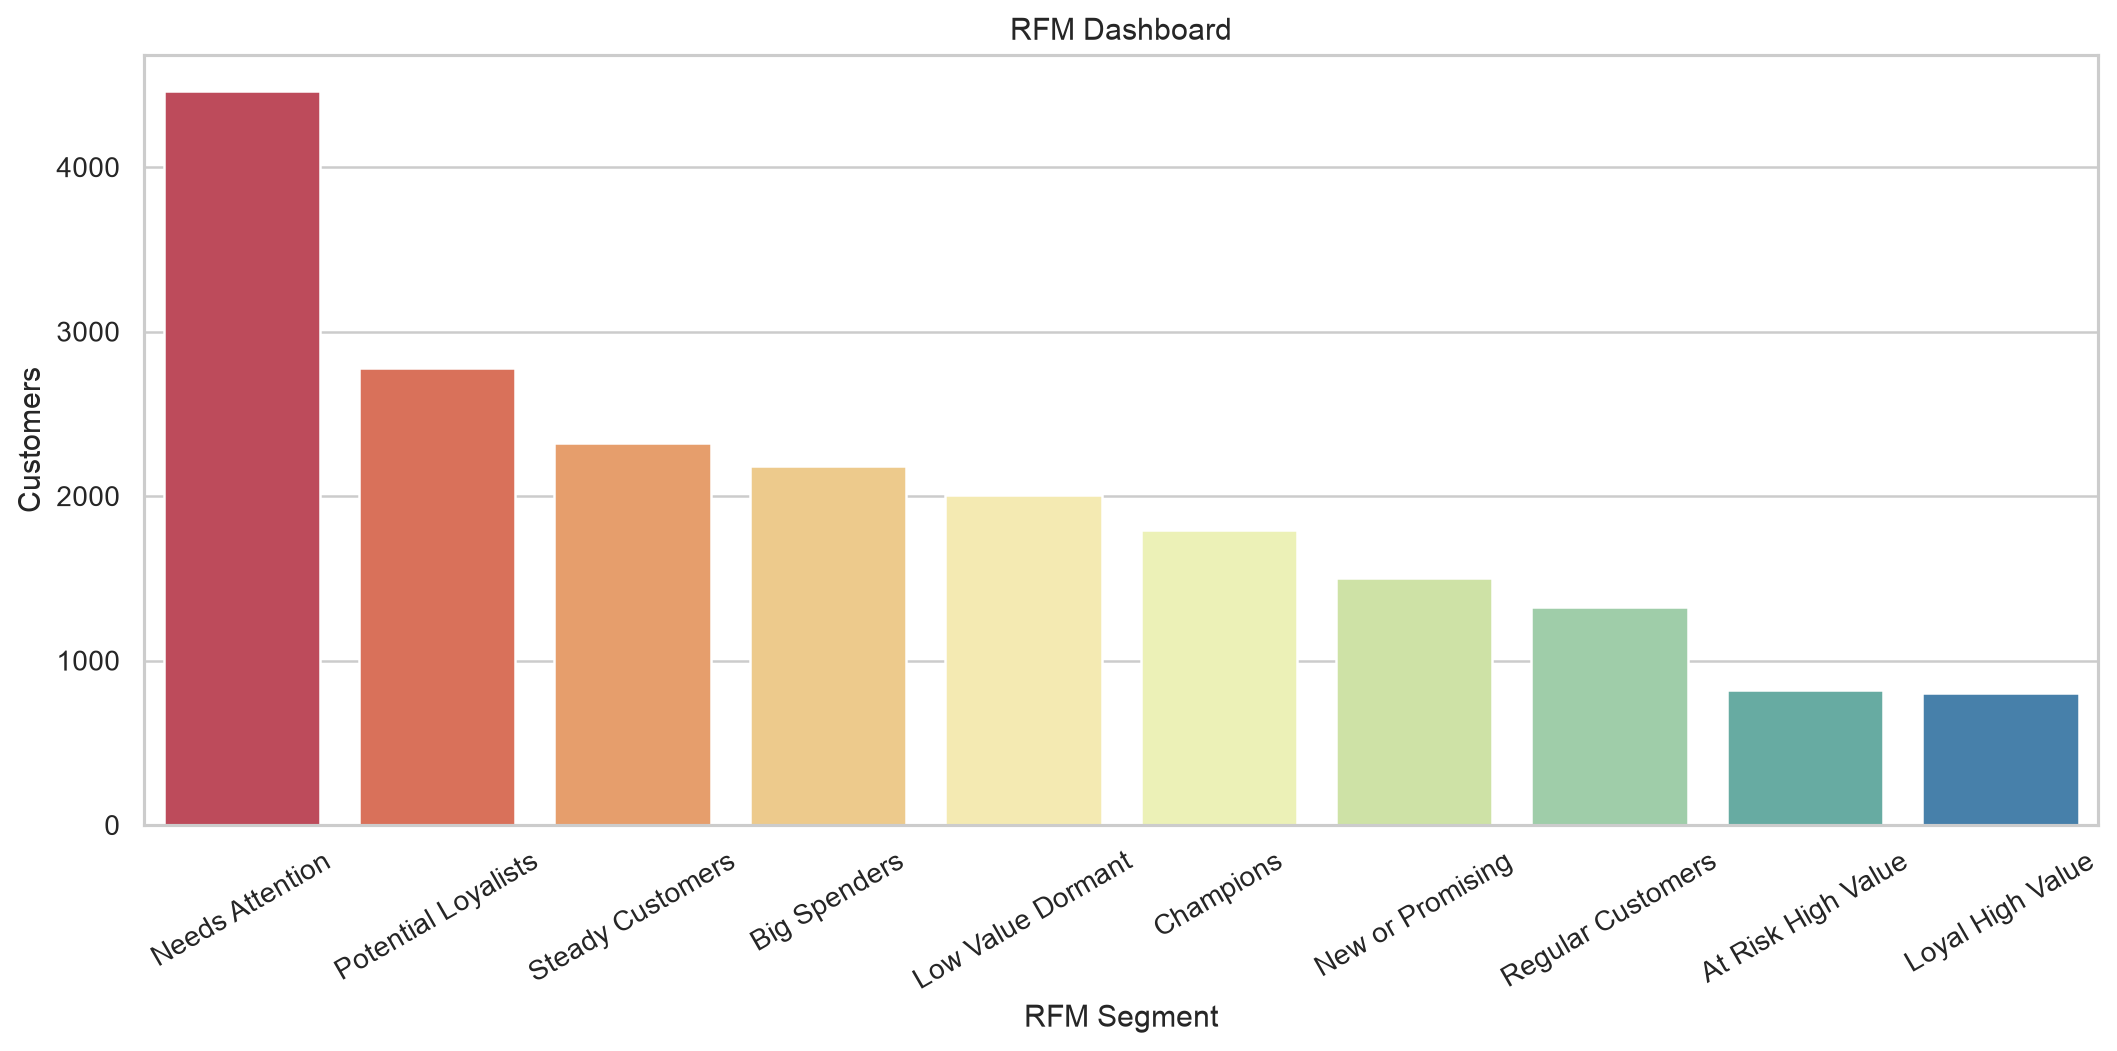

Business insight: RFM dashboard shows the balance between high-value and low-engagement customer groups.


In [20]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
rfm_df = outputs_data.get("rfm_table")
if rfm_df is not None and "rfm_segment" in rfm_df.columns:
    top = rfm_df["rfm_segment"].value_counts().head(10).reset_index()
    top.columns = ["rfm_segment", "count"]
    sns.barplot(data=top, x="rfm_segment", y="count", palette="Spectral", ax=ax)
    ax.set_title("RFM Dashboard")
    ax.set_xlabel("RFM Segment")
    ax.set_ylabel("Customers")
    ax.tick_params(axis="x", rotation=30)
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "RFM output unavailable", ha="center", va="center")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "rfm_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: RFM dashboard shows the balance between high-value and low-engagement customer groups.")

## Profitability Dashboard

Executive view for profitability dashboard.

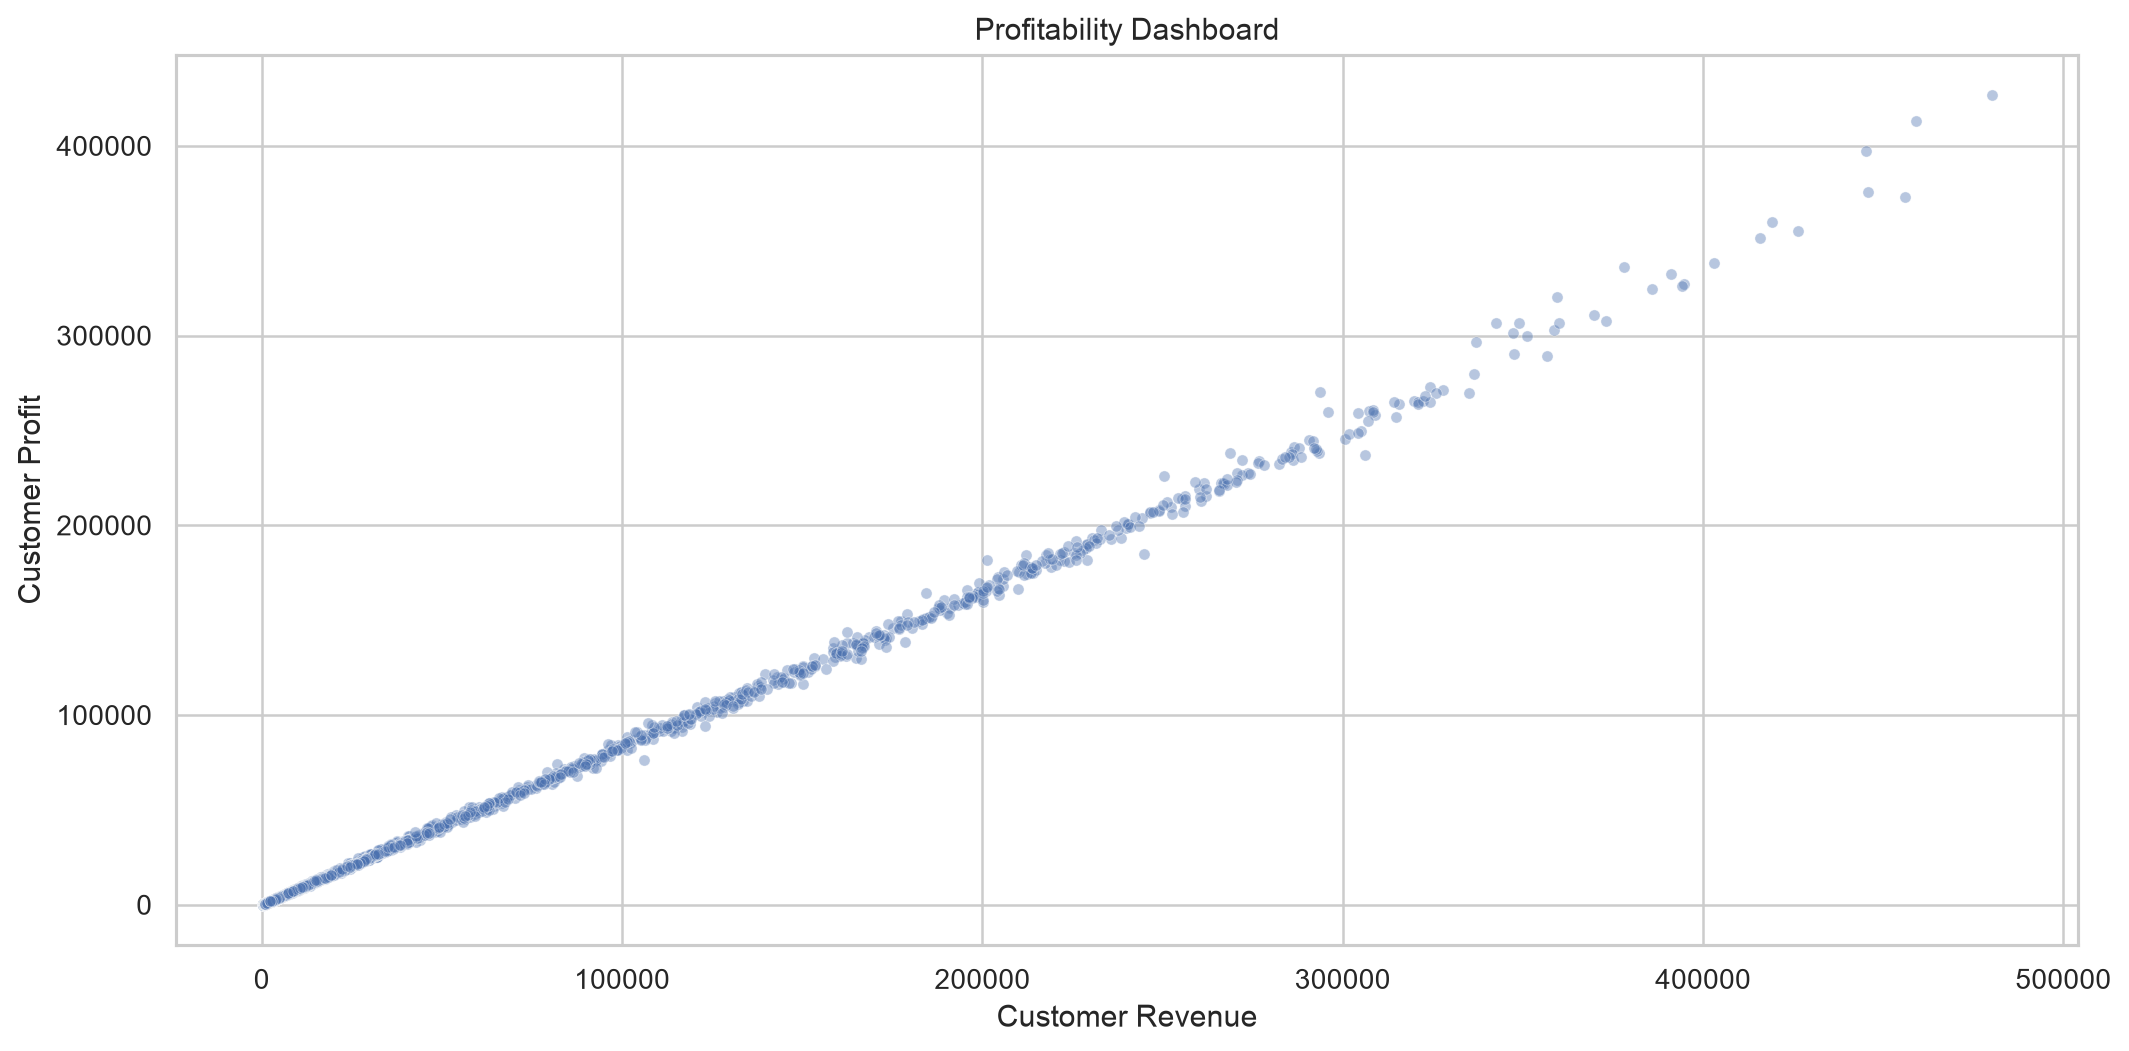

Business insight: profitability dashboard highlights the relationship between revenue contribution and realized profit.


In [21]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
cp = outputs_data.get("customer_profitability")
if cp is not None and {"customer_revenue", "customer_profit"}.issubset(cp.columns):
    sample = cp.sample(min(5000, len(cp)), random_state=42)
    sns.scatterplot(data=sample, x="customer_revenue", y="customer_profit", alpha=0.4, s=20, ax=ax)
    ax.set_title("Profitability Dashboard")
    ax.set_xlabel("Customer Revenue")
    ax.set_ylabel("Customer Profit")
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "Customer profitability output unavailable", ha="center", va="center")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "profitability_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: profitability dashboard highlights the relationship between revenue contribution and realized profit.")

## Executive Business Insights

Section-level insights are consolidated into an exportable executive insights table.

In [22]:
insights = [
    ("Revenue", "Revenue trend and growth remain positive with sustained scale."),
    ("Customers", "Active base is broad, but churn-focused intervention remains important."),
    ("Forecast", "Forecast output provides forward guidance for short-term planning." if not pd.isna(forecast_revenue) else "Forecast output unavailable; planning should rely on historical momentum."),
    ("Cohort", "Retention variation across cohorts signals onboarding and lifecycle optimization opportunities."),
    ("RFM", "RFM segmentation reveals both high-value clusters and at-risk groups requiring targeted campaigns."),
    ("Profitability", "Profitability concentration indicates where scaling and margin defense should be prioritized."),
]
executive_business_insights = pd.DataFrame(insights, columns=["section", "insight"])
print(executive_business_insights.to_string(index=False))

      section                                                                                            insight
      Revenue                                     Revenue trend and growth remain positive with sustained scale.
    Customers                            Active base is broad, but churn-focused intervention remains important.
     Forecast                                 Forecast output provides forward guidance for short-term planning.
       Cohort    Retention variation across cohorts signals onboarding and lifecycle optimization opportunities.
          RFM RFM segmentation reveals both high-value clusters and at-risk groups requiring targeted campaigns.
Profitability      Profitability concentration indicates where scaling and margin defense should be prioritized.


## Executive Recommendations

Actionable recommendations are generated from the dashboard metrics and available risk/performance signals.

In [23]:
risks = []
opportunities = []

if not pd.isna(churn_rate) and churn_rate > 20:
    risks.append("Elevated churn rate may pressure recurring revenue.")
else:
    risks.append("Churn remains manageable but should be monitored by risk segment.")

if profit_margin < 40:
    risks.append("Profit margin compression risk from cost growth.")
else:
    opportunities.append("Healthy profit margin supports reinvestment in growth and retention.")

if not pd.isna(revenue_growth) and revenue_growth < 0:
    risks.append("Revenue contraction risk from weakening trend.")
else:
    opportunities.append("Positive revenue trend can be amplified through high-performing segments.")

opportunities.append("Prioritize high-value RFM segments for expansion and retention offers.")
opportunities.append("Scale top profitability categories and optimize low-contribution channels.")

final_recommendation = "Deploy a dual-track strategy: protect high-risk revenue with retention actions while scaling high-margin segments and channels."

recommendation_rows = []
for item in risks:
    recommendation_rows.append({"type": "Risk", "recommendation": item})
for item in opportunities:
    recommendation_rows.append({"type": "Opportunity", "recommendation": item})
recommendation_rows.append({"type": "Final", "recommendation": final_recommendation})

executive_recommendations = pd.DataFrame(recommendation_rows)
print(executive_recommendations.to_string(index=False))

       type                                                                                                                  recommendation
       Risk                                                                             Elevated churn rate may pressure recurring revenue.
Opportunity                                                            Healthy profit margin supports reinvestment in growth and retention.
Opportunity                                                       Positive revenue trend can be amplified through high-performing segments.
Opportunity                                                          Prioritize high-value RFM segments for expansion and retention offers.
Opportunity                                                      Scale top profitability categories and optimize low-contribution channels.
      Final Deploy a dual-track strategy: protect high-risk revenue with retention actions while scaling high-margin segments and channels.


## Executive Summary

This summary captures the required executive metrics and final recommendation.

In [24]:
summary_items = {
    "Total Revenue": total_revenue,
    "Revenue Growth": revenue_growth,
    "Forecast Revenue": forecast_revenue,
    "Active Customers": active_customers,
    "Churn Rate": churn_rate,
    "Customer Retention": customer_retention,
    "Average CLV": average_clv,
    "Average Order Value": average_order_value,
    "Total Profit": total_profit,
    "Profit Margin": profit_margin,
    "Largest Customer Segment": largest_customer_segment,
    "Highest Revenue Segment": highest_revenue_segment,
    "Highest Profit Segment": highest_profit_segment,
    "Highest CLV Segment": highest_clv_segment,
    "Top Business Risks": " | ".join(risks[:3]),
    "Top Growth Opportunities": " | ".join(opportunities[:3]),
    "Final Business Recommendation": final_recommendation,
}

executive_dashboard_summary = pd.DataFrame(
    [{"metric": key, "value": value} for key, value in summary_items.items()]
)

print(executive_dashboard_summary.to_string(index=False))

                       metric                                                                                                                                                                                                                     value
                Total Revenue                                                                                                                                                                                                              530337543.22
               Revenue Growth                                                                                                                                                                                                             194282.704097
             Forecast Revenue                                                                                                                                                                                                          709544426.570379
        

## Save Dashboard Outputs

All required executive dashboard tables are exported to `outputs/`.

In [25]:
dashboard_metrics = pd.concat(
    [executive_kpis.assign(source="kpi_preparation"), executive_dashboard_summary.assign(source="executive_summary")],
    ignore_index=True,
)

executive_dashboard_summary.to_csv(OUTPUT_DIR / "executive_dashboard_summary.csv", index=False)
executive_kpis.to_csv(OUTPUT_DIR / "executive_kpis.csv", index=False)
dashboard_metrics.to_csv(OUTPUT_DIR / "dashboard_metrics.csv", index=False)
executive_recommendations.to_csv(OUTPUT_DIR / "executive_recommendations.csv", index=False)
executive_business_insights.to_csv(OUTPUT_DIR / "executive_business_insights.csv", index=False)

print("Saved outputs:")
print("-", OUTPUT_DIR / "executive_dashboard_summary.csv")
print("-", OUTPUT_DIR / "executive_kpis.csv")
print("-", OUTPUT_DIR / "dashboard_metrics.csv")
print("-", OUTPUT_DIR / "executive_recommendations.csv")
print("-", OUTPUT_DIR / "executive_business_insights.csv")
print("Executive dashboard notebook completed successfully.")

Saved outputs:
- /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/executive_dashboard_summary.csv
- /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/executive_kpis.csv
- /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/dashboard_metrics.csv
- /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/executive_recommendations.csv
- /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/executive_business_insights.csv
Executive dashboard notebook completed successfully.
